In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
file_path = "pharma-data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 254082
Columns: 18


,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.23,22.57,Hospital,Private,Topipizole,Mood Stabilizers,4.00,368,"1,472.00",January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.42,18.43,Pharmacy,Retail,Choriotrisin,Antibiotics,7.00,591,"4,137.00",January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.08,18.50,Pharmacy,Institution,Acantaine,Antibiotics,30.00,66,"1,980.00",January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.33,19.08,Hospital,Private,Lioletine Refliruvax,Analgesics,6.00,435,"2,610.00",January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.78,20.49,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.00,458,"9,160.00",January,2018,Anne Wu,Britanny Bold,Delta


In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(254082, 18)

Columns:
['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel', 'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep', 'Manager', 'Sales Team']

Data Types:
Distributor              str
Customer Name            str
City                     str
Country                  str
Latitude             float64
Longitude            float64
Channel                  str
Sub-channel              str
Product Name             str
Product Class            str
Quantity             float64
Price                  int64
Sales                float64
Month                    str
Year                   int64
Name of Sales Rep        str
Manager                  str
Sales Team               str
dtype: object

Missing Values:
Distributor          0
Customer Name        0
City                 0
Country              0
Latitude             0
Longitude            0
Channel              0
Sub-channel   

# Cleaning Columns

In [5]:
#cleaning columns
df.columns = df.columns.str.strip()

df.columns = (
    df.columns
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print(df.columns.tolist())

['Distributor', 'Customer_Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel', 'Product_Name', 'Product_Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name_of_Sales_Rep', 'Manager', 'Sales_Team']


# Remove Unnecessary spaces

In [6]:
# Remove unnecessary spaces from text fields
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Text cleaning completed.")

C:\Users\shalini.raj\AppData\Local\Temp\ipykernel_16000\2491494.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


Text cleaning completed.


# Remove duplicates

In [7]:
#check the duplicates in the dataset and cleaning them
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 4
Shape after removing duplicates: (254078, 18)


# checking for negative transactions

In [8]:
#check for negative transactions in the dataset
negative_transactions = df[
    (df["Quantity"] < 0) |
    (df["Sales"] < 0)
]

print("Negative transaction rows:", len(negative_transactions))

negative_transactions.head()

Negative transaction rows: 2633


,Distributor,Customer_Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product_Name,Product_Class,Quantity,Price,Sales,Month,Year,Name_of_Sales_Rep,Manager,Sales_Team
3761,Rohan,"Zieme, Doyle and Kunze",Lublin,Poland,51.23,22.57,Hospital,Private,Exotropin Empizine,Mood Stabilizers,-19.00,785,"-14,915.00",February,2018,Anne Wu,Britanny Bold,Delta
3762,Rohan,Nader-Gaylord Pharmaceutical Limited,Sobótka,Poland,50.90,16.74,Hospital,Private,Epzipitant,Analgesics,-12.00,778,"-9,336.00",February,2018,Thompson Crawford,James Goodwill,Alfa
18526,Rohan,"Buckridge, Dach and Carroll Pharmaceutical Lim...",Luboń,Poland,52.33,16.88,Hospital,Private,Belavarix Benzabicin,Antibiotics,-1.00,131,-131.00,November,2018,Morris Garcia,Tracy Banks,Bravo
22613,Prohaska-Kuhic,"Wiegand, Jast and Yost Pharma Plc",Płock,Poland,52.55,19.70,Hospital,Private,Afinitasol,Antipiretics,-5.00,286,"-1,430.00",February,2018,Jessica Smith,Britanny Bold,Delta
22751,Prohaska-Kuhic,Pfeffer-Hodkiewicz Pharmaceutical Ltd,Szczytno,Poland,53.56,20.99,Hospital,Government,Sucprine Specbalamin,Antiseptics,-50.00,182,"-9,100.00",March,2018,Jimmy Grey,Alisha Cordwell,Charlie


# Forming single date format

In [9]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01",
    errors="coerce"
)

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

df[["Month", "Year", "Date"]].head()

Minimum date: 2017-01-01 00:00:00
Maximum date: 2020-12-01 00:00:00


,Month,Year,Date
0,January,2018,2018-01-01
1,January,2018,2018-01-01
2,January,2018,2018-01-01
3,January,2018,2018-01-01
4,January,2018,2018-01-01


# Dataset statistics

In [10]:
print("Unique Sales Reps:", df["Name_of_Sales_Rep"].nunique())
print("Unique Managers:", df["Manager"].nunique())
print("Unique Sales Teams:", df["Sales_Team"].nunique())
print("Unique Customers:", df["Customer_Name"].nunique())
print("Unique Products:", df["Product_Name"].nunique())
print("Unique Cities:", df["City"].nunique())
print("Unique Countries:", df["Country"].nunique())

Unique Sales Reps: 13
Unique Managers: 4
Unique Sales Teams: 4
Unique Customers: 751
Unique Products: 240
Unique Cities: 749
Unique Countries: 2


# Rep-level sales analysis

In [11]:
rep_sales = (
    df.groupby("Name_of_Sales_Rep")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Transactions=("Sales", "count"),
          Customers=("Customer_Name", "nunique"),
          Products=("Product_Name", "nunique"),
          Cities=("City", "nunique")
      )
      .reset_index()
      .sort_values("Total_Sales", ascending=False)
)

rep_sales

,Name_of_Sales_Rep,Total_Sales,Total_Quantity,Transactions,Customers,Products,Cities
6,Jimmy Grey,"985,969,993.94","2,293,163.73",19503,751,240,749
0,Abigail Thompson,"981,056,993.86","2,301,505.05",19571,751,240,749
9,Sheila Stones,"958,203,898.24","2,384,530.12",19655,751,240,749
3,Daniel Gates,"950,658,635.19","2,310,476.22",19439,751,240,749
2,Anne Wu,"920,168,301.17","2,230,109.10",19563,751,240,749
8,Morris Garcia,"901,195,482.50","2,255,843.81",19461,751,240,749
10,Stella Given,"888,340,902.42","2,109,223.52",19539,751,240,749
5,Jessica Smith,"881,697,619.00","2,143,397.16",19622,751,240,749
11,Steve Pepple,"875,449,982.57","2,237,292.43",19620,751,240,749
7,Mary Gerrard,"875,266,902.91","2,111,202.76",19402,751,240,749


# Rep sales percentage

In [12]:
total_sales = rep_sales["Total_Sales"].sum()

rep_sales["Sales_Percentage"] = (
    rep_sales["Total_Sales"] / total_sales * 100
)

rep_sales

,Name_of_Sales_Rep,Total_Sales,Total_Quantity,Transactions,Customers,Products,Cities,Sales_Percentage
6,Jimmy Grey,"985,969,993.94","2,293,163.73",19503,751,240,749,8.36
0,Abigail Thompson,"981,056,993.86","2,301,505.05",19571,751,240,749,8.31
9,Sheila Stones,"958,203,898.24","2,384,530.12",19655,751,240,749,8.12
3,Daniel Gates,"950,658,635.19","2,310,476.22",19439,751,240,749,8.06
2,Anne Wu,"920,168,301.17","2,230,109.10",19563,751,240,749,7.80
8,Morris Garcia,"901,195,482.50","2,255,843.81",19461,751,240,749,7.64
10,Stella Given,"888,340,902.42","2,109,223.52",19539,751,240,749,7.53
5,Jessica Smith,"881,697,619.00","2,143,397.16",19622,751,240,749,7.47
11,Steve Pepple,"875,449,982.57","2,237,292.43",19620,751,240,749,7.42
7,Mary Gerrard,"875,266,902.91","2,111,202.76",19402,751,240,749,7.42


# Sales by month

In [13]:
monthly_sales = (
    df.groupby("Date")
      .agg(
          Total_Sales=("Sales", "sum"),
          Quantity=("Quantity", "sum"),
          Transactions=("Sales", "count")
      )
      .reset_index()
      .sort_values("Date")
)

monthly_sales.head(12)

,Date,Total_Sales,Quantity,Transactions
0,2017-01-01,"151,872,184.00","357,985.00",4043
1,2017-02-01,"208,995,889.00","529,566.00",4505
2,2017-03-01,"214,767,956.00","532,654.00",4824
3,2017-04-01,"188,799,834.00","450,668.00",3993
4,2017-05-01,"223,634,799.00","588,084.00",5162
5,2017-06-01,"266,668,391.00","653,583.00",4972
6,2017-07-01,"260,488,775.82","594,395.10",5336
7,2017-08-01,"233,834,675.00","544,473.00",5126
8,2017-09-01,"260,251,610.00","645,965.00",4720
9,2017-10-01,"219,338,825.00","530,809.00",4716


# Monthly Sales Trend

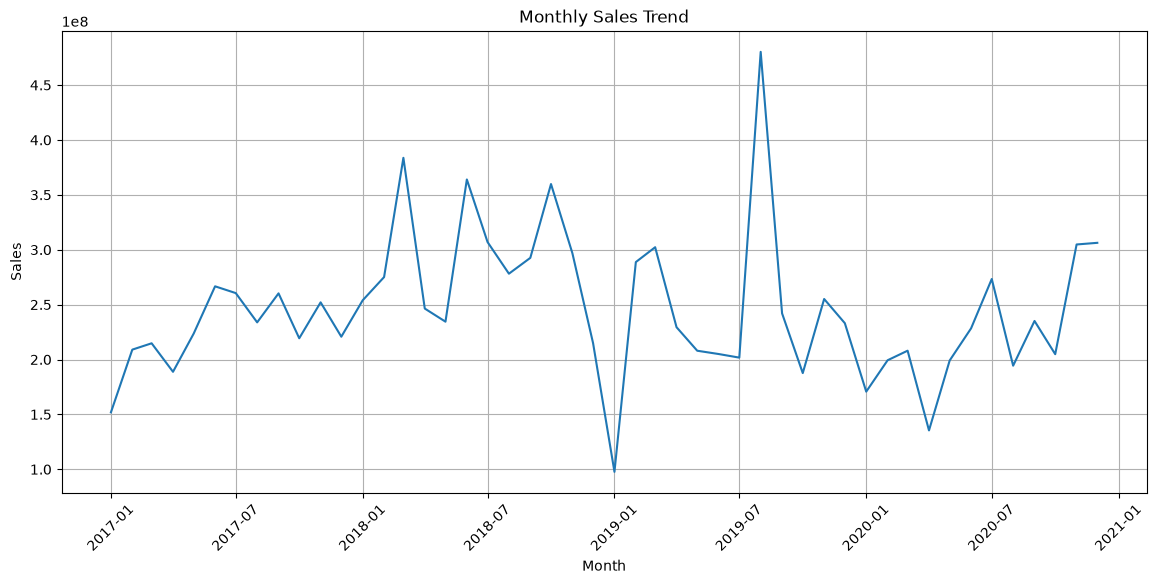

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Total_Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Rep monthly sales

In [15]:
rep_monthly = (
    df.groupby(
        ["Date", "Name_of_Sales_Rep"]
    )
    .agg(
        Sales=("Sales", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Sales", "count"),
        Customers=("Customer_Name", "nunique"),
        Products=("Product_Name", "nunique"),
        Cities=("City", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Name_of_Sales_Rep", "Date"]
    )
)

rep_monthly.head(20)

,Date,Name_of_Sales_Rep,Sales,Quantity,Transactions,Customers,Products,Cities
0,2017-01-01,Abigail Thompson,"12,314,569.00","25,061.00",312,225,176,225
13,2017-02-01,Abigail Thompson,"11,395,787.00","34,346.00",339,249,183,248
26,2017-03-01,Abigail Thompson,"15,080,253.00","39,242.00",359,268,180,267
39,2017-04-01,Abigail Thompson,"12,852,526.00","34,672.00",328,231,175,230
52,2017-05-01,Abigail Thompson,"22,478,781.00","51,748.00",385,267,200,267
65,2017-06-01,Abigail Thompson,"26,704,180.00","49,214.00",343,260,182,260
78,2017-07-01,Abigail Thompson,"36,596,483.31","79,465.55",417,303,197,302
91,2017-08-01,Abigail Thompson,"18,883,791.00","43,714.00",404,273,190,272
104,2017-09-01,Abigail Thompson,"24,368,689.00","75,426.00",357,258,184,257
117,2017-10-01,Abigail Thompson,"16,305,899.00","36,677.00",362,263,185,262


# Previous month sales

In [16]:
rep_monthly["Previous_Month_Sales"] = (
    rep_monthly
    .groupby("Name_of_Sales_Rep")["Sales"]
    .shift(1)
)

rep_monthly.head(20)

,Date,Name_of_Sales_Rep,Sales,Quantity,Transactions,Customers,Products,Cities,Previous_Month_Sales
0,2017-01-01,Abigail Thompson,"12,314,569.00","25,061.00",312,225,176,225,NaN
13,2017-02-01,Abigail Thompson,"11,395,787.00","34,346.00",339,249,183,248,"12,314,569.00"
26,2017-03-01,Abigail Thompson,"15,080,253.00","39,242.00",359,268,180,267,"11,395,787.00"
39,2017-04-01,Abigail Thompson,"12,852,526.00","34,672.00",328,231,175,230,"15,080,253.00"
52,2017-05-01,Abigail Thompson,"22,478,781.00","51,748.00",385,267,200,267,"12,852,526.00"
65,2017-06-01,Abigail Thompson,"26,704,180.00","49,214.00",343,260,182,260,"22,478,781.00"
78,2017-07-01,Abigail Thompson,"36,596,483.31","79,465.55",417,303,197,302,"26,704,180.00"
91,2017-08-01,Abigail Thompson,"18,883,791.00","43,714.00",404,273,190,272,"36,596,483.31"
104,2017-09-01,Abigail Thompson,"24,368,689.00","75,426.00",357,258,184,257,"18,883,791.00"
117,2017-10-01,Abigail Thompson,"16,305,899.00","36,677.00",362,263,185,262,"24,368,689.00"


# Sales change %

In [17]:
rep_monthly["Sales_Change_Pct"] = np.where(
    (
        rep_monthly["Previous_Month_Sales"].notna()
    ) &
    (
        rep_monthly["Previous_Month_Sales"] != 0
    ),
    
    (
        (
            rep_monthly["Sales"]
            -
            rep_monthly["Previous_Month_Sales"]
        )
        /
        rep_monthly["Previous_Month_Sales"]
    ) * 100,
    
    np.nan
)

rep_monthly.head(20)

,Date,Name_of_Sales_Rep,Sales,Quantity,Transactions,Customers,Products,Cities,Previous_Month_Sales,Sales_Change_Pct
0,2017-01-01,Abigail Thompson,"12,314,569.00","25,061.00",312,225,176,225,NaN,NaN
13,2017-02-01,Abigail Thompson,"11,395,787.00","34,346.00",339,249,183,248,"12,314,569.00",-7.46
26,2017-03-01,Abigail Thompson,"15,080,253.00","39,242.00",359,268,180,267,"11,395,787.00",32.33
39,2017-04-01,Abigail Thompson,"12,852,526.00","34,672.00",328,231,175,230,"15,080,253.00",-14.77
52,2017-05-01,Abigail Thompson,"22,478,781.00","51,748.00",385,267,200,267,"12,852,526.00",74.90
65,2017-06-01,Abigail Thompson,"26,704,180.00","49,214.00",343,260,182,260,"22,478,781.00",18.80
78,2017-07-01,Abigail Thompson,"36,596,483.31","79,465.55",417,303,197,302,"26,704,180.00",37.04
91,2017-08-01,Abigail Thompson,"18,883,791.00","43,714.00",404,273,190,272,"36,596,483.31",-48.40
104,2017-09-01,Abigail Thompson,"24,368,689.00","75,426.00",357,258,184,257,"18,883,791.00",29.05
117,2017-10-01,Abigail Thompson,"16,305,899.00","36,677.00",362,263,185,262,"24,368,689.00",-33.09


# Find major sales changes

In [18]:
rep_monthly["Sales_Change_Flag"] = np.where(
    rep_monthly["Sales_Change_Pct"] <= -30,
    "Major Decline",
    np.where(
        rep_monthly["Sales_Change_Pct"] >= 30,
        "Major Increase",
        "Normal"
    )
)

rep_monthly[
    rep_monthly["Sales_Change_Flag"] != "Normal"
].sort_values(
    "Sales_Change_Pct"
).head(30)

,Date,Name_of_Sales_Rep,Sales,Quantity,Transactions,Customers,Products,Cities,Previous_Month_Sales,Sales_Change_Pct,Sales_Change_Flag
316,2019-01-01,Erica Jones,"4,283,482.00","11,584.00",274,217,170,216,"18,013,990.00",-76.22,Major Decline
418,2019-09-01,Anne Wu,"11,890,461.00","34,890.00",309,236,170,236,"47,331,346.00",-74.88,Major Decline
359,2019-04-01,Morris Garcia,"9,460,289.00","32,494.00",312,245,175,245,"35,641,515.00",-73.46,Major Decline
317,2019-01-01,Jessica Smith,"7,080,773.00","16,218.00",304,235,177,235,"25,266,417.00",-71.98,Major Decline
195,2018-04-01,Abigail Thompson,"11,890,083.80","29,580.20",530,375,209,375,"39,779,125.00",-70.11,Major Decline
318,2019-01-01,Jimmy Grey,"4,836,314.00","13,301.00",253,208,163,208,"15,490,491.00",-68.78,Major Decline
423,2019-09-01,Mary Gerrard,"10,597,560.00","29,520.00",307,232,183,232,"33,341,224.00",-68.21,Major Decline
206,2018-04-01,Steve Pepple,"11,405,398.00","37,089.00",550,388,214,388,"35,772,107.00",-68.12,Major Decline
427,2019-09-01,Steve Pepple,"15,679,002.00","39,345.00",334,243,190,243,"48,967,718.00",-67.98,Major Decline
568,2020-08-01,Sheila Stones,"10,260,486.00","26,308.00",320,244,182,244,"31,977,150.00",-67.91,Major Decline


# Find the biggest sales declines

In [19]:
major_declines = (
    rep_monthly[
        rep_monthly["Sales_Change_Pct"].notna()
    ]
    .sort_values("Sales_Change_Pct")
)

major_declines[
    [
        "Date",
        "Name_of_Sales_Rep",
        "Sales",
        "Previous_Month_Sales",
        "Sales_Change_Pct"
    ]
].head(20)

,Date,Name_of_Sales_Rep,Sales,Previous_Month_Sales,Sales_Change_Pct
316,2019-01-01,Erica Jones,"4,283,482.00","18,013,990.00",-76.22
418,2019-09-01,Anne Wu,"11,890,461.00","47,331,346.00",-74.88
359,2019-04-01,Morris Garcia,"9,460,289.00","35,641,515.00",-73.46
317,2019-01-01,Jessica Smith,"7,080,773.00","25,266,417.00",-71.98
195,2018-04-01,Abigail Thompson,"11,890,083.80","39,779,125.00",-70.11
318,2019-01-01,Jimmy Grey,"4,836,314.00","15,490,491.00",-68.78
423,2019-09-01,Mary Gerrard,"10,597,560.00","33,341,224.00",-68.21
206,2018-04-01,Steve Pepple,"11,405,398.00","35,772,107.00",-68.12
427,2019-09-01,Steve Pepple,"15,679,002.00","48,967,718.00",-67.98
568,2020-08-01,Sheila Stones,"10,260,486.00","31,977,150.00",-67.91


# Find biggest sales increases

In [20]:
major_increases = (
    rep_monthly[
        rep_monthly["Sales_Change_Pct"].notna()
    ]
    .sort_values(
        "Sales_Change_Pct",
        ascending=False
    )
)

major_increases[
    [
        "Date",
        "Name_of_Sales_Rep",
        "Sales",
        "Previous_Month_Sales",
        "Sales_Change_Pct"
    ]
].head(20)

,Date,Name_of_Sales_Rep,Sales,Previous_Month_Sales,Sales_Change_Pct
331,2019-02-01,Jimmy Grey,"40,163,923.00","4,836,314.00",730.47
409,2019-08-01,Jimmy Grey,"85,075,616.00","11,064,896.00",668.88
329,2019-02-01,Erica Jones,"26,569,377.00","4,283,482.00",520.28
601,2020-11-01,Daniel Gates,"34,780,064.00","6,676,694.00",420.92
328,2019-02-01,Daniel Gates,"27,993,912.00","6,138,913.00",356.01
413,2019-08-01,Stella Given,"45,973,840.00","10,595,139.00",333.91
595,2020-10-01,Stella Given,"67,091,636.00","18,857,410.00",255.78
227,2018-06-01,Jimmy Grey,"49,287,965.00","14,828,214.00",232.39
408,2019-08-01,Jessica Smith,"36,126,171.00","10,903,440.00",231.33
405,2019-08-01,Anne Wu,"47,331,346.00","14,515,823.00",226.07


# Rep performance chart

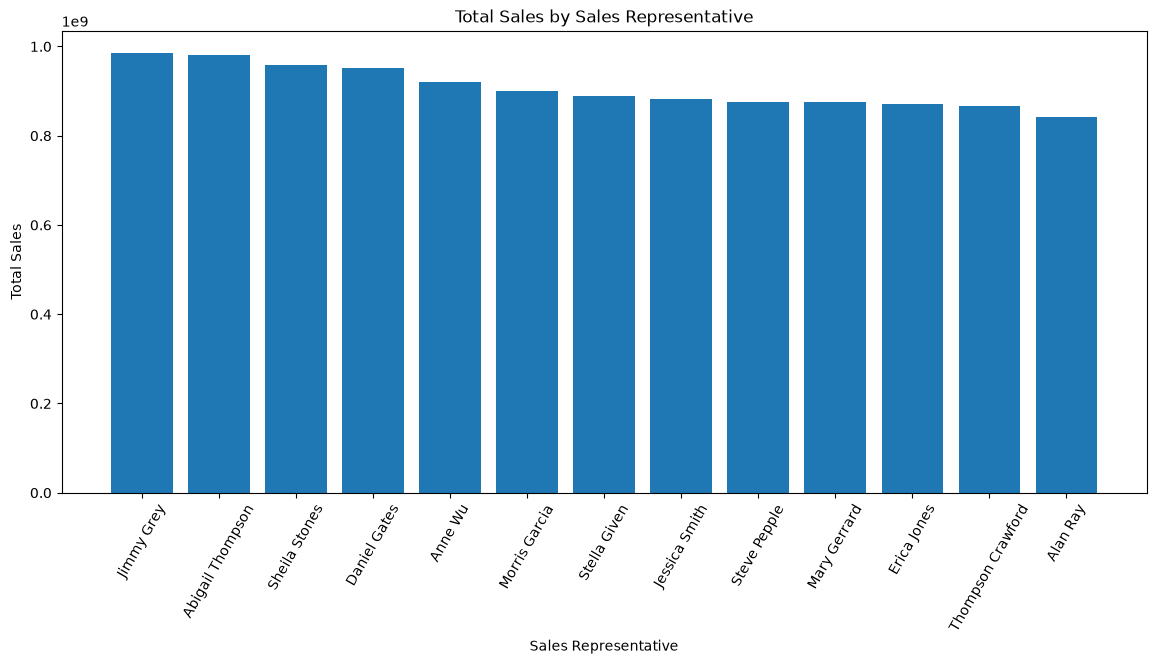

In [21]:
plt.figure(figsize=(14, 6))

plt.bar(
    rep_sales["Name_of_Sales_Rep"],
    rep_sales["Total_Sales"]
)

plt.title("Total Sales by Sales Representative")
plt.xlabel("Sales Representative")
plt.ylabel("Total Sales")
plt.xticks(rotation=60)

plt.show()

# Manager analysis

In [22]:
manager_sales = (
    df.groupby("Manager")
      .agg(
          Total_Sales=("Sales", "sum"),
          Reps=("Name_of_Sales_Rep", "nunique"),
          Customers=("Customer_Name", "nunique"),
          Products=("Product_Name", "nunique")
      )
      .reset_index()
)

manager_sales["Sales_Per_Rep"] = (
    manager_sales["Total_Sales"] /
    manager_sales["Reps"]
)

manager_sales.sort_values(
    "Total_Sales",
    ascending=False
)

,Manager,Total_Sales,Reps,Customers,Products,Sales_Per_Rep
1,Britanny Bold,"3,635,336,721.33",4,751,240,"908,834,180.33"
0,Alisha Cordwell,"2,824,969,531.55",3,751,240,"941,656,510.52"
3,Tracy Banks,"2,757,702,458.94",3,751,240,"919,234,152.98"
2,James Goodwill,"2,580,969,030.38",3,751,240,"860,323,010.13"


# Sales team analysis

In [23]:
team_sales = (
    df.groupby("Sales_Team")
      .agg(
          Total_Sales=("Sales", "sum"),
          Reps=("Name_of_Sales_Rep", "nunique"),
          Customers=("Customer_Name", "nunique"),
          Products=("Product_Name", "nunique")
      )
      .reset_index()
)

team_sales["Sales_Per_Rep"] = (
    team_sales["Total_Sales"] /
    team_sales["Reps"]
)

team_sales.sort_values(
    "Total_Sales",
    ascending=False
)

,Sales_Team,Total_Sales,Reps,Customers,Products,Sales_Per_Rep
3,Delta,"3,635,336,721.33",4,751,240,"908,834,180.33"
2,Charlie,"2,824,969,531.55",3,751,240,"941,656,510.52"
1,Bravo,"2,757,702,458.94",3,751,240,"919,234,152.98"
0,Alfa,"2,580,969,030.38",3,751,240,"860,323,010.13"


# Product analysis

In [24]:
product_sales = (
    df.groupby(
        ["Product_Class", "Product_Name"]
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Sales", "count")
    )
    .reset_index()
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

product_sales.head(20)

,Product_Class,Product_Name,Total_Sales,Quantity,Transactions
22,Analgesics,Ionclotide,"169,083,391.00","267,961.00",1093
108,Antimalarial,Tetratanyl,"126,091,294.00","246,754.00",1071
35,Analgesics,Sumanazole,"113,861,431.00","215,239.00",1122
12,Analgesics,Betanem,"107,073,473.00","175,243.00",1044
168,Antiseptics,Docstryl Rivacin,"103,811,886.00","131,574.00",1110
192,Antiseptics,Travoloride,"101,167,660.00","128,876.00",1075
100,Antimalarial,Propratecan,"100,878,712.00","147,916.00",1108
23,Analgesics,Ketastadil,"97,313,783.00","127,541.00",1081
64,Antibiotics,Nevanide Actozide,"96,643,552.00","125,024.00",1137
53,Antibiotics,Cephozumab Synmethate,"95,320,320.00","124,115.00",1050


# Country analysis

In [25]:
country_sales = (
    df.groupby("Country")
      .agg(
          Total_Sales=("Sales", "sum"),
          Quantity=("Quantity", "sum"),
          Customers=("Customer_Name", "nunique"),
          Reps=("Name_of_Sales_Rep", "nunique")
      )
      .reset_index()
)

country_sales["Sales_Per_Rep"] = (
    country_sales["Total_Sales"] /
    country_sales["Reps"]
)

country_sales

,Country,Total_Sales,Quantity,Customers,Reps,Sales_Per_Rep
0,Germany,"11,118,101,800.40","27,004,395.60",551,13,"855,238,600.03"
1,Poland,"680,875,941.80","1,674,323.20",200,13,"52,375,072.45"


# Risk Dataset creation

In [26]:
risk_df = rep_monthly.copy()

# Initial business thresholds
risk_df["Sales_Risk"] = np.where(
    risk_df["Sales_Change_Pct"] <= -30,
    2,
    np.where(
        risk_df["Sales_Change_Pct"] <= -15,
        1,
        0
    )
)

risk_df["Risk_Label"] = np.select(
    [
        risk_df["Sales_Risk"] == 2,
        risk_df["Sales_Risk"] == 1
    ],
    [
        "Major",
        "Minor"
    ],
    default="Normal"
)

risk_df[
    [
        "Date",
        "Name_of_Sales_Rep",
        "Sales",
        "Previous_Month_Sales",
        "Sales_Change_Pct",
        "Sales_Risk",
        "Risk_Label"
    ]
].head(20)

,Date,Name_of_Sales_Rep,Sales,Previous_Month_Sales,Sales_Change_Pct,Sales_Risk,Risk_Label
0,2017-01-01,Abigail Thompson,"12,314,569.00",NaN,NaN,0,Normal
13,2017-02-01,Abigail Thompson,"11,395,787.00","12,314,569.00",-7.46,0,Normal
26,2017-03-01,Abigail Thompson,"15,080,253.00","11,395,787.00",32.33,0,Normal
39,2017-04-01,Abigail Thompson,"12,852,526.00","15,080,253.00",-14.77,0,Normal
52,2017-05-01,Abigail Thompson,"22,478,781.00","12,852,526.00",74.90,0,Normal
65,2017-06-01,Abigail Thompson,"26,704,180.00","22,478,781.00",18.80,0,Normal
78,2017-07-01,Abigail Thompson,"36,596,483.31","26,704,180.00",37.04,0,Normal
91,2017-08-01,Abigail Thompson,"18,883,791.00","36,596,483.31",-48.40,2,Major
104,2017-09-01,Abigail Thompson,"24,368,689.00","18,883,791.00",29.05,0,Normal
117,2017-10-01,Abigail Thompson,"16,305,899.00","24,368,689.00",-33.09,2,Major


In [27]:
rep_monthly.to_csv(
    "rep_monthly_analysis.csv",
    index=False
)

risk_df.to_csv(
    "rep_sales_risk_analysis.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


# Create the actual rep master from your existing sales data

In [28]:
# Create the actual rep master from your existing sales data

rep_master = (
    df[
        [
            "Name_of_Sales_Rep",
            "Manager",
            "Sales_Team"
        ]
    ]
    .drop_duplicates()
    .sort_values("Name_of_Sales_Rep")
    .reset_index(drop=True)
)

# Create a unique Rep ID
rep_master["Rep_ID"] = [
    f"REP_{i:03d}"
    for i in range(1, len(rep_master) + 1)
]

# Reorder columns
rep_master = rep_master[
    [
        "Rep_ID",
        "Name_of_Sales_Rep",
        "Manager",
        "Sales_Team"
    ]
]

print("Number of reps:", len(rep_master))
rep_master

Number of reps: 13


,Rep_ID,Name_of_Sales_Rep,Manager,Sales_Team
0,REP_001,Abigail Thompson,Tracy Banks,Bravo
1,REP_002,Alan Ray,James Goodwill,Alfa
2,REP_003,Anne Wu,Britanny Bold,Delta
3,REP_004,Daniel Gates,Alisha Cordwell,Charlie
4,REP_005,Erica Jones,James Goodwill,Alfa
5,REP_006,Jessica Smith,Britanny Bold,Delta
6,REP_007,Jimmy Grey,Alisha Cordwell,Charlie
7,REP_008,Mary Gerrard,Britanny Bold,Delta
8,REP_009,Morris Garcia,Tracy Banks,Bravo
9,REP_010,Sheila Stones,Britanny Bold,Delta


# Create Territory mapping

In [29]:
# Get unique cities
cities = sorted(df["City"].dropna().unique())

print("Number of cities:", len(cities))
print("First 20 cities:")
print(cities[:20])

Number of cities: 749
First 20 cities:
['Aachen', 'Aalen', 'Achern', 'Achim', 'Ahaus', 'Ahlen', 'Ahrensburg', 'Aichach', 'Albstadt', 'Alsdorf', 'Altenburg', 'Alzey', 'Amberg', 'Andernach', 'Annaberg-Buchholz', 'Ansbach', 'Apolda', 'Arnsberg', 'Arnstadt', 'Aschaffenburg']


# Create synthetic territories

In [30]:
# Number of territories for our hackathon demo
num_territories = 20

# Assign cities to territories in a reproducible way
city_to_territory = {
    city: f"TERR_{(i % num_territories) + 1:02d}"
    for i, city in enumerate(cities)
}

# Add Territory to sales data
df["Territory_ID"] = df["City"].map(city_to_territory)

print("Territories created:", df["Territory_ID"].nunique())

df[
    [
        "City",
        "Territory_ID"
    ]
].drop_duplicates().head(20)

Territories created: 20


,City,Territory_ID
0,Lublin,TERR_11
1,Świecie,TERR_05
2,Rybnik,TERR_06
3,Czeladź,TERR_05
4,Olsztyn,TERR_07
5,Olecko,TERR_05
6,Inowrocław,TERR_20
7,Ciechanów,TERR_15
8,Nidzica,TERR_01
9,Kraków,TERR_04


# Find which reps operate in which territories

In [31]:
rep_territory = (
    df.groupby(
        [
            "Name_of_Sales_Rep",
            "Manager",
            "Sales_Team"
        ]
    )
    .agg(
        Territories=("Territory_ID", "nunique"),
        Cities=("City", "nunique")
    )
    .reset_index()
)

rep_territory

,Name_of_Sales_Rep,Manager,Sales_Team,Territories,Cities
0,Abigail Thompson,Tracy Banks,Bravo,20,749
1,Alan Ray,James Goodwill,Alfa,20,749
2,Anne Wu,Britanny Bold,Delta,20,749
3,Daniel Gates,Alisha Cordwell,Charlie,20,749
4,Erica Jones,James Goodwill,Alfa,20,749
5,Jessica Smith,Britanny Bold,Delta,20,749
6,Jimmy Grey,Alisha Cordwell,Charlie,20,749
7,Mary Gerrard,Britanny Bold,Delta,20,749
8,Morris Garcia,Tracy Banks,Bravo,20,749
9,Sheila Stones,Britanny Bold,Delta,20,749


# Create Rep → Territory assignment

In [32]:
rep_territory_sales = (
    df.groupby(
        [
            "Name_of_Sales_Rep",
            "Territory_ID"
        ]
    )
    .agg(
        Sales=("Sales", "sum")
    )
    .reset_index()
)

# Select the territory with the highest sales for each rep
primary_territory = (
    rep_territory_sales
    .sort_values(
        ["Name_of_Sales_Rep", "Sales"],
        ascending=[True, False]
    )
    .drop_duplicates("Name_of_Sales_Rep")
    .rename(
        columns={
            "Territory_ID": "Primary_Territory"
        }
    )
)

primary_territory.head(20)

,Name_of_Sales_Rep,Primary_Territory,Sales
12,Abigail Thompson,TERR_13,"73,834,247.00"
23,Alan Ray,TERR_04,"56,206,109.00"
43,Anne Wu,TERR_04,"87,547,366.00"
64,Daniel Gates,TERR_05,"66,193,017.00"
92,Erica Jones,TERR_13,"51,097,715.00"
115,Jessica Smith,TERR_16,"60,931,831.00"
136,Jimmy Grey,TERR_17,"112,584,848.00"
142,Mary Gerrard,TERR_03,"55,231,190.00"
178,Morris Garcia,TERR_19,"57,018,908.00"
183,Sheila Stones,TERR_04,"67,460,092.00"


# Add territory to Rep Master

In [33]:
rep_master = rep_master.merge(
    primary_territory[
        [
            "Name_of_Sales_Rep",
            "Primary_Territory"
        ]
    ],
    on="Name_of_Sales_Rep",
    how="left"
)

rep_master

,Rep_ID,Name_of_Sales_Rep,Manager,Sales_Team,Primary_Territory
0,REP_001,Abigail Thompson,Tracy Banks,Bravo,TERR_13
1,REP_002,Alan Ray,James Goodwill,Alfa,TERR_04
2,REP_003,Anne Wu,Britanny Bold,Delta,TERR_04
3,REP_004,Daniel Gates,Alisha Cordwell,Charlie,TERR_05
4,REP_005,Erica Jones,James Goodwill,Alfa,TERR_13
5,REP_006,Jessica Smith,Britanny Bold,Delta,TERR_16
6,REP_007,Jimmy Grey,Alisha Cordwell,Charlie,TERR_17
7,REP_008,Mary Gerrard,Britanny Bold,Delta,TERR_03
8,REP_009,Morris Garcia,Tracy Banks,Bravo,TERR_19
9,REP_010,Sheila Stones,Britanny Bold,Delta,TERR_04


# Create synthetic HR information

In [34]:
np.random.seed(42)

# Start with all reps active
rep_master["Employment_Status"] = "Active"

# Create synthetic join dates
rep_master["Join_Date"] = pd.to_datetime(
    np.random.choice(
        pd.date_range("2017-01-01", "2019-12-01", freq="MS"),
        size=len(rep_master),
        replace=True
    )
)

# Initialize exit dates
rep_master["Exit_Date"] = pd.NaT

# Select a few reps to simulate exits
vacancy_reps = [
    rep_master.iloc[2]["Rep_ID"],
    rep_master.iloc[7]["Rep_ID"],
    rep_master.iloc[10]["Rep_ID"]
]

# Synthetic exit dates
exit_dates = [
    pd.Timestamp("2019-06-15"),
    pd.Timestamp("2020-02-15"),
    pd.Timestamp("2020-07-15")
]

for rep_id, exit_date in zip(vacancy_reps, exit_dates):
    rep_master.loc[
        rep_master["Rep_ID"] == rep_id,
        "Exit_Date"
    ] = exit_date

    rep_master.loc[
        rep_master["Rep_ID"] == rep_id,
        "Employment_Status"
    ] = "Exited"

rep_master

,Rep_ID,Name_of_Sales_Rep,Manager,Sales_Team,Primary_Territory,Employment_Status,Join_Date,Exit_Date
0,REP_001,Abigail Thompson,Tracy Banks,Bravo,TERR_13,Active,2019-05-01,NaT
1,REP_002,Alan Ray,James Goodwill,Alfa,TERR_04,Active,2018-03-01,NaT
2,REP_003,Anne Wu,Britanny Bold,Delta,TERR_04,Exited,2017-08-01,2019-06-15
3,REP_004,Daniel Gates,Alisha Cordwell,Charlie,TERR_05,Active,2018-09-01,NaT
4,REP_005,Erica Jones,James Goodwill,Alfa,TERR_13,Active,2018-07-01,NaT
5,REP_006,Jessica Smith,Britanny Bold,Delta,TERR_16,Active,2018-11-01,NaT
6,REP_007,Jimmy Grey,Alisha Cordwell,Charlie,TERR_17,Active,2017-11-01,NaT
7,REP_008,Mary Gerrard,Britanny Bold,Delta,TERR_03,Exited,2017-11-01,2020-02-15
8,REP_009,Morris Garcia,Tracy Banks,Bravo,TERR_19,Active,2018-12-01,NaT
9,REP_010,Sheila Stones,Britanny Bold,Delta,TERR_04,Active,2019-12-01,NaT


# Create vacancy information

In [35]:
# Required reps per territory
# This is a demo business assumption and should be validated with Kartik.

territory_rep_counts = (
    rep_master
    .groupby("Primary_Territory")
    .size()
    .reset_index(name="Current_Reps")
)

territory_rep_counts["Required_Reps"] = (
    territory_rep_counts["Current_Reps"] + 1
)

territory_rep_counts["Vacancy_Count"] = (
    territory_rep_counts["Required_Reps"]
    -
    territory_rep_counts["Current_Reps"]
)

territory_rep_counts

,Primary_Territory,Current_Reps,Required_Reps,Vacancy_Count
0,TERR_01,1,2,1
1,TERR_03,1,2,1
2,TERR_04,4,5,1
3,TERR_05,1,2,1
4,TERR_13,2,3,1
5,TERR_16,1,2,1
6,TERR_17,2,3,1
7,TERR_19,1,2,1


# Calculate vacancy duration

In [36]:
analysis_date = pd.Timestamp("2020-12-31")

rep_master["Vacancy_Days"] = np.where(
    rep_master["Exit_Date"].notna(),
    (
        analysis_date -
        rep_master["Exit_Date"]
    ).dt.days,
    0
)

rep_master[
    [
        "Rep_ID",
        "Name_of_Sales_Rep",
        "Employment_Status",
        "Join_Date",
        "Exit_Date",
        "Vacancy_Days"
    ]
]

,Rep_ID,Name_of_Sales_Rep,Employment_Status,Join_Date,Exit_Date,Vacancy_Days
0,REP_001,Abigail Thompson,Active,2019-05-01,NaT,0.00
1,REP_002,Alan Ray,Active,2018-03-01,NaT,0.00
2,REP_003,Anne Wu,Exited,2017-08-01,2019-06-15,565.00
3,REP_004,Daniel Gates,Active,2018-09-01,NaT,0.00
4,REP_005,Erica Jones,Active,2018-07-01,NaT,0.00
5,REP_006,Jessica Smith,Active,2018-11-01,NaT,0.00
6,REP_007,Jimmy Grey,Active,2017-11-01,NaT,0.00
7,REP_008,Mary Gerrard,Exited,2017-11-01,2020-02-15,320.00
8,REP_009,Morris Garcia,Active,2018-12-01,NaT,0.00
9,REP_010,Sheila Stones,Active,2019-12-01,NaT,0.00


# Create Vacancy Flag

In [37]:
rep_master["Vacancy_Flag"] = np.where(
    rep_master["Employment_Status"] == "Exited",
    1,
    0
)

rep_master[
    [
        "Rep_ID",
        "Name_of_Sales_Rep",
        "Primary_Territory",
        "Employment_Status",
        "Vacancy_Flag",
        "Vacancy_Days"
    ]
]

,Rep_ID,Name_of_Sales_Rep,Primary_Territory,Employment_Status,Vacancy_Flag,Vacancy_Days
0,REP_001,Abigail Thompson,TERR_13,Active,0,0.00
1,REP_002,Alan Ray,TERR_04,Active,0,0.00
2,REP_003,Anne Wu,TERR_04,Exited,1,565.00
3,REP_004,Daniel Gates,TERR_05,Active,0,0.00
4,REP_005,Erica Jones,TERR_13,Active,0,0.00
5,REP_006,Jessica Smith,TERR_16,Active,0,0.00
6,REP_007,Jimmy Grey,TERR_17,Active,0,0.00
7,REP_008,Mary Gerrard,TERR_03,Exited,1,320.00
8,REP_009,Morris Garcia,TERR_19,Active,0,0.00
9,REP_010,Sheila Stones,TERR_04,Active,0,0.00


# Create territory-level HR view

In [38]:
territory_hr = (
    rep_master
    .groupby("Primary_Territory")
    .agg(
        Current_Reps=("Rep_ID", "count"),
        Vacancies=("Vacancy_Flag", "sum"),
        Max_Vacancy_Days=("Vacancy_Days", "max")
    )
    .reset_index()
)

territory_hr["Required_Reps"] = (
    territory_hr["Current_Reps"] + 
    territory_hr["Vacancies"]
)

territory_hr

,Primary_Territory,Current_Reps,Vacancies,Max_Vacancy_Days,Required_Reps
0,TERR_01,1,1,169.00,2
1,TERR_03,1,1,320.00,2
2,TERR_04,4,1,565.00,5
3,TERR_05,1,0,0.00,1
4,TERR_13,2,0,0.00,2
5,TERR_16,1,0,0.00,1
6,TERR_17,2,0,0.00,2
7,TERR_19,1,0,0.00,1


# Connect territory HR data to sales

In [39]:
territory_sales = (
    df.groupby(
        [
            "Date",
            "Territory_ID"
        ]
    )
    .agg(
        Sales=("Sales", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Sales", "count"),
        Customers=("Customer_Name", "nunique"),
        Products=("Product_Name", "nunique")
    )
    .reset_index()
)

territory_sales.head()

,Date,Territory_ID,Sales,Quantity,Transactions,Customers,Products
0,2017-01-01,TERR_01,"10,335,194.00","26,595.00",201,25,139
1,2017-01-01,TERR_02,"6,250,409.00","15,584.00",203,30,147
2,2017-01-01,TERR_03,"5,654,805.00","13,752.00",219,30,141
3,2017-01-01,TERR_04,"6,014,958.00","13,143.00",207,29,134
4,2017-01-01,TERR_05,"4,006,651.00","11,244.00",179,25,128


# Add territory sales trend

In [40]:
territory_sales = territory_sales.sort_values(
    [
        "Territory_ID",
        "Date"
    ]
)

territory_sales["Previous_Month_Sales"] = (
    territory_sales
    .groupby("Territory_ID")["Sales"]
    .shift(1)
)

territory_sales["Sales_Change_Pct"] = np.where(
    territory_sales["Previous_Month_Sales"].notna() &
    (territory_sales["Previous_Month_Sales"] != 0),
    
    (
        (
            territory_sales["Sales"] -
            territory_sales["Previous_Month_Sales"]
        )
        /
        territory_sales["Previous_Month_Sales"]
    ) * 100,
    
    np.nan
)

territory_sales.head(20)

,Date,Territory_ID,Sales,Quantity,Transactions,Customers,Products,Previous_Month_Sales,Sales_Change_Pct
0,2017-01-01,TERR_01,"10,335,194.00","26,595.00",201,25,139,NaN,NaN
20,2017-02-01,TERR_01,"11,739,667.00","26,699.00",189,25,130,"10,335,194.00",13.59
40,2017-03-01,TERR_01,"10,575,375.00","27,134.00",245,25,152,"11,739,667.00",-9.92
60,2017-04-01,TERR_01,"9,858,937.00","22,024.00",176,25,124,"10,575,375.00",-6.77
80,2017-05-01,TERR_01,"8,382,731.00","22,421.00",242,25,156,"9,858,937.00",-14.97
100,2017-06-01,TERR_01,"7,095,749.00","20,327.00",218,25,148,"8,382,731.00",-15.35
120,2017-07-01,TERR_01,"11,013,668.00","25,496.00",244,25,149,"7,095,749.00",55.22
140,2017-08-01,TERR_01,"15,435,015.00","30,431.00",235,25,150,"11,013,668.00",40.14
160,2017-09-01,TERR_01,"11,918,410.00","25,860.00",239,25,143,"15,435,015.00",-22.78
180,2017-10-01,TERR_01,"13,154,248.00","27,129.00",201,24,129,"11,918,410.00",10.37


# Connect HR with territory sales

In [41]:
territory_analysis = territory_sales.merge(
    territory_hr,
    left_on="Territory_ID",
    right_on="Primary_Territory",
    how="left"
)

territory_analysis.head()

,Date,Territory_ID,Sales,Quantity,Transactions,Customers,Products,Previous_Month_Sales,Sales_Change_Pct,Primary_Territory,Current_Reps,Vacancies,Max_Vacancy_Days,Required_Reps
0,2017-01-01,TERR_01,"10,335,194.00","26,595.00",201,25,139,NaN,NaN,TERR_01,1.00,1.00,169.00,2.00
1,2017-02-01,TERR_01,"11,739,667.00","26,699.00",189,25,130,"10,335,194.00",13.59,TERR_01,1.00,1.00,169.00,2.00
2,2017-03-01,TERR_01,"10,575,375.00","27,134.00",245,25,152,"11,739,667.00",-9.92,TERR_01,1.00,1.00,169.00,2.00
3,2017-04-01,TERR_01,"9,858,937.00","22,024.00",176,25,124,"10,575,375.00",-6.77,TERR_01,1.00,1.00,169.00,2.00
4,2017-05-01,TERR_01,"8,382,731.00","22,421.00",242,25,156,"9,858,937.00",-14.97,TERR_01,1.00,1.00,169.00,2.00


# Create initial vacancy risk
using demo thresholds 

In [42]:
territory_analysis["Vacancy_Risk"] = np.where(
    territory_analysis["Vacancies"] >= 1,
    1,
    0
)

territory_analysis["Sales_Risk"] = np.where(
    territory_analysis["Sales_Change_Pct"] <= -30,
    2,
    np.where(
        territory_analysis["Sales_Change_Pct"] <= -15,
        1,
        0
    )
)

territory_analysis["Overall_Risk_Score"] = (
    territory_analysis["Vacancy_Risk"] * 40 +
    territory_analysis["Sales_Risk"] * 30
)

# Convert score to severity

In [43]:
territory_analysis["Severity"] = np.select(
    [
        territory_analysis["Overall_Risk_Score"] >= 70,
        territory_analysis["Overall_Risk_Score"] >= 40
    ],
    [
        "Critical",
        "Major"
    ],
    default="Minor"
)

territory_analysis[
    [
        "Date",
        "Territory_ID",
        "Sales",
        "Sales_Change_Pct",
        "Vacancies",
        "Vacancy_Risk",
        "Overall_Risk_Score",
        "Severity"
    ]
].head(30)

,Date,Territory_ID,Sales,Sales_Change_Pct,Vacancies,Vacancy_Risk,Overall_Risk_Score,Severity
0,2017-01-01,TERR_01,"10,335,194.00",NaN,1.00,1,40,Major
1,2017-02-01,TERR_01,"11,739,667.00",13.59,1.00,1,40,Major
2,2017-03-01,TERR_01,"10,575,375.00",-9.92,1.00,1,40,Major
3,2017-04-01,TERR_01,"9,858,937.00",-6.77,1.00,1,40,Major
4,2017-05-01,TERR_01,"8,382,731.00",-14.97,1.00,1,40,Major
5,2017-06-01,TERR_01,"7,095,749.00",-15.35,1.00,1,70,Critical
6,2017-07-01,TERR_01,"11,013,668.00",55.22,1.00,1,40,Major
7,2017-08-01,TERR_01,"15,435,015.00",40.14,1.00,1,40,Major
8,2017-09-01,TERR_01,"11,918,410.00",-22.78,1.00,1,70,Critical
9,2017-10-01,TERR_01,"13,154,248.00",10.37,1.00,1,40,Major


# Create a management summary

In [44]:
management_summary = (
    territory_analysis
    .sort_values("Date")
    .groupby("Territory_ID")
    .tail(1)
    [
        [
            "Territory_ID",
            "Sales",
            "Sales_Change_Pct",
            "Current_Reps",
            "Required_Reps",
            "Vacancies",
            "Max_Vacancy_Days",
            "Overall_Risk_Score",
            "Severity"
        ]
    ]
    .sort_values(
        "Overall_Risk_Score",
        ascending=False
    )
)

management_summary

,Territory_ID,Sales,Sales_Change_Pct,Current_Reps,Required_Reps,Vacancies,Max_Vacancy_Days,Overall_Risk_Score,Severity
863,TERR_18,"13,741,271.00",-49.99,NaN,NaN,NaN,NaN,60,Major
767,TERR_16,"13,694,971.00",-53.67,1.00,1.00,0.00,0.00,60,Major
527,TERR_11,"5,882,209.00",-73.25,NaN,NaN,NaN,NaN,60,Major
383,TERR_08,"8,865,415.00",-71.59,NaN,NaN,NaN,NaN,60,Major
191,TERR_04,"19,046,548.00",10.38,4.00,5.00,1.00,565.00,40,Major
143,TERR_03,"33,582,810.00",68.64,1.00,2.00,1.00,320.00,40,Major
47,TERR_01,"12,472,018.00",24.13,1.00,2.00,1.00,169.00,40,Major
479,TERR_10,"12,517,068.00",82.58,NaN,NaN,NaN,NaN,0,Minor
95,TERR_02,"14,598,321.00",37.38,NaN,NaN,NaN,NaN,0,Minor
287,TERR_06,"14,425,583.00",5.08,NaN,NaN,NaN,NaN,0,Minor


# Save Phase 2 datasets

In [45]:
# Save Rep Master
rep_master.to_csv(
    "rep_master_hr.csv",
    index=False
)

# Save territory HR information
territory_hr.to_csv(
    "territory_hr_analysis.csv",
    index=False
)

# Save territory sales + HR analysis
territory_analysis.to_csv(
    "territory_vacancy_analysis.csv",
    index=False
)

# Save management summary
management_summary.to_csv(
    "management_summary.csv",
    index=False
)

print("files created successfully!")

files created successfully!


# CRM ACTIVITY

In [46]:
np.random.seed(42)

# Use actual combinations from our sales data
crm_base = (
    df[
        [
            "Date",
            "Name_of_Sales_Rep",
            "Territory_ID",
            "Customer_Name"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Add Rep_ID
crm_base = crm_base.merge(
    rep_master[
        [
            "Rep_ID",
            "Name_of_Sales_Rep"
        ]
    ],
    on="Name_of_Sales_Rep",
    how="left"
)

crm_base = crm_base.rename(
    columns={
        "Customer_Name": "HCP_ID"
    }
)

print("CRM base records:", len(crm_base))
crm_base.head()

CRM base records: 181122


,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Rep_ID
0,2018-01-01,Mary Gerrard,TERR_11,"Zieme, Doyle and Kunze",REP_008
1,2018-01-01,Jessica Smith,TERR_05,Feest PLC,REP_006
2,2018-01-01,Steve Pepple,TERR_06,Medhurst-Beer Pharmaceutical Limited,REP_012
3,2018-01-01,Mary Gerrard,TERR_05,Barton Ltd Pharma Plc,REP_008
4,2018-01-01,Anne Wu,TERR_07,Keeling LLC Pharmacy,REP_003


In [47]:
# Create planned activity

crm_base["Planned_Calls"] = np.random.randint(
    5,
    16,
    size=len(crm_base)
)

crm_base["Planned_Visits"] = np.random.randint(
    2,
    8,
    size=len(crm_base)
)

crm_base.head()

,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Rep_ID,Planned_Calls,Planned_Visits
0,2018-01-01,Mary Gerrard,TERR_11,"Zieme, Doyle and Kunze",REP_008,11,7
1,2018-01-01,Jessica Smith,TERR_05,Feest PLC,REP_006,8,4
2,2018-01-01,Steve Pepple,TERR_06,Medhurst-Beer Pharmaceutical Limited,REP_012,15,6
3,2018-01-01,Mary Gerrard,TERR_05,Barton Ltd Pharma Plc,REP_008,12,6
4,2018-01-01,Anne Wu,TERR_07,Keeling LLC Pharmacy,REP_003,9,5


In [48]:
# Actual activity is generally around the planned activity,
# but we intentionally introduce some low-activity situations.

activity_factor = np.random.normal(
    loc=0.90,
    scale=0.20,
    size=len(crm_base)
)

activity_factor = np.clip(
    activity_factor,
    0.30,
    1.20
)

crm_base["Actual_Calls"] = np.round(
    crm_base["Planned_Calls"] * activity_factor
).astype(int)

crm_base["Actual_Visits"] = np.round(
    crm_base["Planned_Visits"] * activity_factor
).astype(int)

crm_base.head()

,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Rep_ID,Planned_Calls,Planned_Visits,Actual_Calls,Actual_Visits
0,2018-01-01,Mary Gerrard,TERR_11,"Zieme, Doyle and Kunze",REP_008,11,7,9,6
1,2018-01-01,Jessica Smith,TERR_05,Feest PLC,REP_006,8,4,8,4
2,2018-01-01,Steve Pepple,TERR_06,Medhurst-Beer Pharmaceutical Limited,REP_012,15,6,14,6
3,2018-01-01,Mary Gerrard,TERR_05,Barton Ltd Pharma Plc,REP_008,12,6,13,6
4,2018-01-01,Anne Wu,TERR_07,Keeling LLC Pharmacy,REP_003,9,5,11,6


In [49]:
# Actual activity is generally around the planned activity,
# but we intentionally introduce some low-activity situations.

activity_factor = np.random.normal(
    loc=0.90,
    scale=0.20,
    size=len(crm_base)
)

activity_factor = np.clip(
    activity_factor,
    0.30,
    1.20
)

crm_base["Actual_Calls"] = np.round(
    crm_base["Planned_Calls"] * activity_factor
).astype(int)

crm_base["Actual_Visits"] = np.round(
    crm_base["Planned_Visits"] * activity_factor
).astype(int)

crm_base.head()

,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Rep_ID,Planned_Calls,Planned_Visits,Actual_Calls,Actual_Visits
0,2018-01-01,Mary Gerrard,TERR_11,"Zieme, Doyle and Kunze",REP_008,11,7,8,5
1,2018-01-01,Jessica Smith,TERR_05,Feest PLC,REP_006,8,4,8,4
2,2018-01-01,Steve Pepple,TERR_06,Medhurst-Beer Pharmaceutical Limited,REP_012,15,6,6,2
3,2018-01-01,Mary Gerrard,TERR_05,Barton Ltd Pharma Plc,REP_008,12,6,10,5
4,2018-01-01,Anne Wu,TERR_07,Keeling LLC Pharmacy,REP_003,9,5,7,4


In [51]:
hcp_monthly = (
    crm_base
    .groupby(
        [
            "Date",
            "Rep_ID",
            "Name_of_Sales_Rep",
            "Territory_ID"
        ]
    )
    .agg(
        Total_HCPs=("HCP_ID", "nunique"),
        HCPs_Visited=(
            "Actual_Visits",
            lambda x: (x > 0).sum()
        ),
        Planned_Calls=("Planned_Calls", "sum"),
        Actual_Calls=("Actual_Calls", "sum"),
        Planned_Visits=("Planned_Visits", "sum"),
        Actual_Visits=("Actual_Visits", "sum")
    )
    .reset_index()
)

hcp_monthly["HCP_Coverage_%"] = (
    hcp_monthly["HCPs_Visited"] /
    hcp_monthly["Total_HCPs"] * 100
)

hcp_monthly["Activity_%"] = (
    (
        hcp_monthly["Actual_Calls"] /
        hcp_monthly["Planned_Calls"]
    ) +
    (
        hcp_monthly["Actual_Visits"] /
        hcp_monthly["Planned_Visits"]
    )
) / 2 * 100

hcp_monthly.head()

,Date,Rep_ID,Name_of_Sales_Rep,Territory_ID,Total_HCPs,HCPs_Visited,Planned_Calls,Actual_Calls,Planned_Visits,Actual_Visits,HCP_Coverage_%,Activity_%
0,2017-01-01,REP_001,Abigail Thompson,TERR_01,10,10,92,74,40,32,100.00,80.22
1,2017-01-01,REP_001,Abigail Thompson,TERR_02,13,13,122,107,60,50,100.00,85.52
2,2017-01-01,REP_001,Abigail Thompson,TERR_03,13,13,126,115,60,55,100.00,91.47
3,2017-01-01,REP_001,Abigail Thompson,TERR_04,12,12,108,105,58,57,100.00,97.75
4,2017-01-01,REP_001,Abigail Thompson,TERR_05,11,11,103,87,58,48,100.00,83.61


In [52]:
hcp_monthly["CRM_Risk"] = np.select(
    [
        hcp_monthly["Activity_%"] < 60,
        hcp_monthly["Activity_%"] < 80
    ],
    [
        "Critical",
        "Major"
    ],
    default="Normal"
)

hcp_monthly[
    [
        "Date",
        "Rep_ID",
        "Name_of_Sales_Rep",
        "Territory_ID",
        "Activity_%",
        "HCP_Coverage_%",
        "CRM_Risk"
    ]
].head(20)

,Date,Rep_ID,Name_of_Sales_Rep,Territory_ID,Activity_%,HCP_Coverage_%,CRM_Risk
0,2017-01-01,REP_001,Abigail Thompson,TERR_01,80.22,100.00,Normal
1,2017-01-01,REP_001,Abigail Thompson,TERR_02,85.52,100.00,Normal
2,2017-01-01,REP_001,Abigail Thompson,TERR_03,91.47,100.00,Normal
3,2017-01-01,REP_001,Abigail Thompson,TERR_04,97.75,100.00,Normal
4,2017-01-01,REP_001,Abigail Thompson,TERR_05,83.61,100.00,Normal
5,2017-01-01,REP_001,Abigail Thompson,TERR_06,93.61,100.00,Normal
6,2017-01-01,REP_001,Abigail Thompson,TERR_07,93.11,100.00,Normal
7,2017-01-01,REP_001,Abigail Thompson,TERR_08,77.02,100.00,Major
8,2017-01-01,REP_001,Abigail Thompson,TERR_09,94.86,100.00,Normal
9,2017-01-01,REP_001,Abigail Thompson,TERR_10,93.66,100.00,Normal


In [53]:
hcp_monthly = hcp_monthly.sort_values(
    [
        "Rep_ID",
        "Date"
    ]
)

hcp_monthly["Previous_Activity_%"] = (
    hcp_monthly
    .groupby("Rep_ID")["Activity_%"]
    .shift(1)
)

hcp_monthly["CRM_Activity_Change_%"] = np.where(
    hcp_monthly["Previous_Activity_%"].notna() &
    (hcp_monthly["Previous_Activity_%"] != 0),

    (
        (
            hcp_monthly["Activity_%"] -
            hcp_monthly["Previous_Activity_%"]
        )
        /
        hcp_monthly["Previous_Activity_%"]
    ) * 100,

    np.nan
)

hcp_monthly.head(20)

,Date,Rep_ID,Name_of_Sales_Rep,Territory_ID,Total_HCPs,HCPs_Visited,Planned_Calls,Actual_Calls,Planned_Visits,Actual_Visits,HCP_Coverage_%,Activity_%,CRM_Risk,Previous_Activity_%,CRM_Activity_Change_%
0,2017-01-01,REP_001,Abigail Thompson,TERR_01,10,10,92,74,40,32,100.00,80.22,Normal,NaN,NaN
1,2017-01-01,REP_001,Abigail Thompson,TERR_02,13,13,122,107,60,50,100.00,85.52,Normal,80.22,6.61
2,2017-01-01,REP_001,Abigail Thompson,TERR_03,13,13,126,115,60,55,100.00,91.47,Normal,85.52,6.96
3,2017-01-01,REP_001,Abigail Thompson,TERR_04,12,12,108,105,58,57,100.00,97.75,Normal,91.47,6.87
4,2017-01-01,REP_001,Abigail Thompson,TERR_05,11,11,103,87,58,48,100.00,83.61,Normal,97.75,-14.46
5,2017-01-01,REP_001,Abigail Thompson,TERR_06,9,9,95,88,37,35,100.00,93.61,Normal,83.61,11.96
6,2017-01-01,REP_001,Abigail Thompson,TERR_07,14,14,151,138,58,55,100.00,93.11,Normal,93.61,-0.54
7,2017-01-01,REP_001,Abigail Thompson,TERR_08,14,14,124,95,62,48,100.00,77.02,Major,93.11,-17.28
8,2017-01-01,REP_001,Abigail Thompson,TERR_09,9,9,71,67,43,41,100.00,94.86,Normal,77.02,23.17
9,2017-01-01,REP_001,Abigail Thompson,TERR_10,12,12,114,106,53,50,100.00,93.66,Normal,94.86,-1.26


In [54]:
crm_declines = (
    hcp_monthly[
        hcp_monthly["CRM_Activity_Change_%"].notna()
    ]
    .sort_values(
        "CRM_Activity_Change_%"
    )
)

crm_declines[
    [
        "Date",
        "Rep_ID",
        "Name_of_Sales_Rep",
        "Territory_ID",
        "Activity_%",
        "Previous_Activity_%",
        "CRM_Activity_Change_%",
        "HCP_Coverage_%"
    ]
].head(20)

,Date,Rep_ID,Name_of_Sales_Rep,Territory_ID,Activity_%,Previous_Activity_%,CRM_Activity_Change_%,HCP_Coverage_%
7155,2019-04-01,REP_007,Jimmy Grey,TERR_16,68.40,95.67,-28.51,100.00
6694,2019-02-01,REP_010,Sheila Stones,TERR_15,72.24,100.00,-27.76,100.00
6324,2019-01-01,REP_005,Erica Jones,TERR_05,72.71,99.80,-27.14,100.00
10364,2020-04-01,REP_012,Steve Pepple,TERR_05,71.45,97.54,-26.75,100.00
11898,2020-10-01,REP_010,Sheila Stones,TERR_19,73.68,100.48,-26.67,100.00
11816,2020-10-01,REP_006,Jessica Smith,TERR_17,72.37,98.17,-26.28,100.00
2920,2017-12-01,REP_004,Daniel Gates,TERR_01,68.62,92.65,-25.94,100.00
11803,2020-10-01,REP_006,Jessica Smith,TERR_04,70.90,95.45,-25.72,100.00
6585,2019-02-01,REP_005,Erica Jones,TERR_06,76.38,102.80,-25.70,100.00
767,2017-03-01,REP_013,Thompson Crawford,TERR_08,75.53,101.46,-25.55,100.00


# Promotional Activity

In [55]:

np.random.seed(100)

promotion_base = (
    df[
        [
            "Date",
            "Name_of_Sales_Rep",
            "Territory_ID",
            "Customer_Name",
            "Product_Name",
            "Product_Class"
        ]
    ]
    .drop_duplicates()
)

promotion_base = promotion_base.merge(
    rep_master[
        [
            "Rep_ID",
            "Name_of_Sales_Rep"
        ]
    ],
    on="Name_of_Sales_Rep",
    how="left"
)

promotion_base = promotion_base.rename(
    columns={
        "Customer_Name": "HCP_ID"
    }
)

# Randomly select a subset as promotional activities
promotion_data = promotion_base.sample(
    frac=0.08,
    random_state=42
).reset_index(drop=True)

print("Promotional activity records:", len(promotion_data))

promotion_data.head()

Promotional activity records: 20295


,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Product_Name,Product_Class,Rep_ID
0,2020-05-01,Thompson Crawford,TERR_07,White Inc Pharmacy,Xenaminphen,Antimalarial,REP_013
1,2018-12-01,Jessica Smith,TERR_08,Gibson-Hill,Alemtuvatol Megalinum,Analgesics,REP_006
2,2019-03-01,Erica Jones,TERR_16,Funk PLC Pharma Plc,Diaxolol,Antiseptics,REP_005
3,2018-06-01,Mary Gerrard,TERR_11,Raynor-Graham Pharma Plc,Relenstrel Exurabine,Antibiotics,REP_008
4,2020-09-01,Jimmy Grey,TERR_11,Pfeffer-Hodkiewicz Pharm,Panpion,Antiseptics,REP_007


In [57]:
# Aggregate sales by month, rep, customer and product

sales_monthly_detail = (
    df.groupby(
        [
            "Date",
            "Name_of_Sales_Rep",
            "Customer_Name",
            "Product_Name"
        ]
    )
    .agg(
        Sales=("Sales", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

sales_monthly_detail.head()

,Date,Name_of_Sales_Rep,Customer_Name,Product_Name,Sales,Quantity
0,2017-01-01,Abigail Thompson,"Armstrong, Medhurst and Bogisich Pharmaceutica...",Cortirodine Alimcline,"-5,120.00",-40.00
1,2017-01-01,Abigail Thompson,Balistreri-Watsica Pharma Plc,Clinicilin Pentozone,"5,600.00",50.00
2,2017-01-01,Abigail Thompson,Balistreri-Watsica Pharma Plc,Megenorphine,"16,080.00",40.00
3,2017-01-01,Abigail Thompson,Barrows Inc Pharmacy,Dorzovorin Pentadarone,"88,560.00",540.00
4,2017-01-01,Abigail Thompson,Barrows Inc Pharmacy,Kinovatol,"1,850.00",5.00


In [58]:
sales_monthly_detail = sales_monthly_detail.sort_values(
    [
        "Name_of_Sales_Rep",
        "Customer_Name",
        "Product_Name",
        "Date"
    ]
)

sales_monthly_detail["Previous_Month_Sales"] = (
    sales_monthly_detail
    .groupby(
        [
            "Name_of_Sales_Rep",
            "Customer_Name",
            "Product_Name"
        ]
    )["Sales"]
    .shift(1)
)

sales_monthly_detail["Next_Month_Sales"] = (
    sales_monthly_detail
    .groupby(
        [
            "Name_of_Sales_Rep",
            "Customer_Name",
            "Product_Name"
        ]
    )["Sales"]
    .shift(-1)
)

sales_monthly_detail.head(20)

,Date,Name_of_Sales_Rep,Customer_Name,Product_Name,Sales,Quantity,Previous_Month_Sales,Next_Month_Sales
163899,2019-04-01,Abigail Thompson,Abernathy Group,Aciprex,"16,840.00",40.00,NaN,NaN
17344,2017-05-01,Abigail Thompson,Abernathy Group,Agalsiline,"32,000.00",500.00,NaN,NaN
182777,2019-08-01,Abigail Thompson,Abernathy Group,Alarudin Azarolac,"113,400.00",200.00,NaN,NaN
125670,2018-10-01,Abigail Thompson,Abernathy Group,Algluconium Dorzofoxin,"12,220.00",20.00,NaN,NaN
150662,2019-01-01,Abigail Thompson,Abernathy Group,Alpradipine,"27,590.00",62.00,NaN,NaN
221560,2020-06-01,Abigail Thompson,Abernathy Group,Amlominphen Dexanovate,"6,902.00",58.00,NaN,NaN
13356,2017-04-01,Abigail Thompson,Abernathy Group,Apromin,"-3,750.00",-10.00,NaN,NaN
173183,2019-06-01,Abigail Thompson,Abernathy Group,Betanem,"76,375.00",125.00,NaN,NaN
150663,2019-01-01,Abigail Thompson,Abernathy Group,Ceftatana Serolamide,"3,570.00",6.00,NaN,NaN
125671,2018-10-01,Abigail Thompson,Abernathy Group,Ceretosine,"3,430.00",10.00,NaN,NaN


In [59]:
promotion_data = promotion_data.merge(
    sales_monthly_detail[
        [
            "Date",
            "Name_of_Sales_Rep",
            "Customer_Name",
            "Product_Name",
            "Sales",
            "Previous_Month_Sales",
            "Next_Month_Sales"
        ]
    ],
    left_on=[
        "Date",
        "Name_of_Sales_Rep",
        "HCP_ID",
        "Product_Name"
    ],
    right_on=[
        "Date",
        "Name_of_Sales_Rep",
        "Customer_Name",
        "Product_Name"
    ],
    how="left"
)

promotion_data.head()

,Date,Name_of_Sales_Rep,Territory_ID,HCP_ID,Product_Name,Product_Class,Rep_ID,Promotion_Type,Customer_Name,Sales,Previous_Month_Sales,Next_Month_Sales
0,2020-05-01,Thompson Crawford,TERR_07,White Inc Pharmacy,Xenaminphen,Antimalarial,REP_013,Product Presentation,White Inc Pharmacy,"214,500.00",NaN,NaN
1,2018-12-01,Jessica Smith,TERR_08,Gibson-Hill,Alemtuvatol Megalinum,Analgesics,REP_006,Product Presentation,Gibson-Hill,"40,920.00",NaN,NaN
2,2019-03-01,Erica Jones,TERR_16,Funk PLC Pharma Plc,Diaxolol,Antiseptics,REP_005,Educational Session,Funk PLC Pharma Plc,"7,650.00",NaN,"153,000.00"
3,2018-06-01,Mary Gerrard,TERR_11,Raynor-Graham Pharma Plc,Relenstrel Exurabine,Antibiotics,REP_008,Product Presentation,Raynor-Graham Pharma Plc,"4,240.00",NaN,NaN
4,2020-09-01,Jimmy Grey,TERR_11,Pfeffer-Hodkiewicz Pharm,Panpion,Antiseptics,REP_007,Product Demonstration,Pfeffer-Hodkiewicz Pharm,"6,920.00",NaN,NaN


In [60]:
promotion_data["Sales_Before"] = (
    promotion_data["Previous_Month_Sales"]
)

promotion_data["Sales_After"] = (
    promotion_data["Next_Month_Sales"]
)

promotion_data["Sales_Uplift_%"] = np.where(
    promotion_data["Sales_Before"].notna() &
    (promotion_data["Sales_Before"] != 0) &
    promotion_data["Sales_After"].notna(),

    (
        (
            promotion_data["Sales_After"] -
            promotion_data["Sales_Before"]
        )
        /
        promotion_data["Sales_Before"]
    ) * 100,

    np.nan
)

promotion_data[
    [
        "Date",
        "Name_of_Sales_Rep",
        "HCP_ID",
        "Product_Name",
        "Promotion_Type",
        "Sales_Before",
        "Sales_After",
        "Sales_Uplift_%"
    ]
].head(20)

,Date,Name_of_Sales_Rep,HCP_ID,Product_Name,Promotion_Type,Sales_Before,Sales_After,Sales_Uplift_%
0,2020-05-01,Thompson Crawford,White Inc Pharmacy,Xenaminphen,Product Presentation,NaN,NaN,NaN
1,2018-12-01,Jessica Smith,Gibson-Hill,Alemtuvatol Megalinum,Product Presentation,NaN,NaN,NaN
2,2019-03-01,Erica Jones,Funk PLC Pharma Plc,Diaxolol,Educational Session,NaN,"153,000.00",NaN
3,2018-06-01,Mary Gerrard,Raynor-Graham Pharma Plc,Relenstrel Exurabine,Product Presentation,NaN,NaN,NaN
4,2020-09-01,Jimmy Grey,Pfeffer-Hodkiewicz Pharm,Panpion,Product Demonstration,NaN,NaN,NaN
5,2017-07-01,Jessica Smith,"Armstrong, Medhurst and Bogisich Pharmacy",Propralamide Dexlanzolam,Campaign,NaN,NaN,NaN
6,2018-08-01,Mary Gerrard,Koss-Beier,Abtasol,Product Demonstration,NaN,NaN,NaN
7,2019-12-01,Morris Garcia,Hartmann-Wolf Pharmaceutical Limited,Testant,Product Demonstration,NaN,NaN,NaN
8,2019-11-01,Sheila Stones,"Wintheiser, Breitenberg and Gottlieb",Abobozolid,Product Demonstration,NaN,NaN,NaN
9,2017-09-01,Daniel Gates,Schulist-Zulauf Pharmaceutical Ltd,Symbitrim,Product Demonstration,NaN,NaN,NaN


In [61]:
promotion_data["Promotion_Impact"] = np.select(
    [
        promotion_data["Sales_Uplift_%"] >= 20,
        promotion_data["Sales_Uplift_%"] >= 5,
        promotion_data["Sales_Uplift_%"] < 5
    ],
    [
        "High Impact",
        "Moderate Impact",
        "Low/No Impact"
    ],
    default="Insufficient Data"
)

promotion_data[
    [
        "Promotion_Type",
        "Sales_Uplift_%",
        "Promotion_Impact"
    ]
].head(20)

,Promotion_Type,Sales_Uplift_%,Promotion_Impact
0,Product Presentation,NaN,Insufficient Data
1,Product Presentation,NaN,Insufficient Data
2,Educational Session,NaN,Insufficient Data
3,Product Presentation,NaN,Insufficient Data
4,Product Demonstration,NaN,Insufficient Data
5,Campaign,NaN,Insufficient Data
6,Product Demonstration,NaN,Insufficient Data
7,Product Demonstration,NaN,Insufficient Data
8,Product Demonstration,NaN,Insufficient Data
9,Product Demonstration,NaN,Insufficient Data


In [62]:
promotion_summary = (
    promotion_data
    .groupby("Promotion_Impact")
    .agg(
        Activities=("Promotion_Type", "count"),
        Average_Sales_Uplift=("Sales_Uplift_%", "mean")
    )
    .reset_index()
)

promotion_summary

,Promotion_Impact,Activities,Average_Sales_Uplift
0,High Impact,18,"3,635.53"
1,Insufficient Data,20254,NaN
2,Low/No Impact,23,-57.54


In [63]:
product_promotion_impact = (
    promotion_data
    .groupby(
        [
            "Product_Class",
            "Product_Name"
        ]
    )
    .agg(
        Activities=("Promotion_Type", "count"),
        Average_Sales_Uplift=("Sales_Uplift_%", "mean")
    )
    .reset_index()
    .sort_values(
        "Average_Sales_Uplift",
        ascending=False
    )
)

product_promotion_impact.head(20)

,Product_Class,Product_Name,Activities,Average_Sales_Uplift
36,Analgesics,Symbitrim,98,"54,900.00"
53,Antibiotics,Cephozumab Synmethate,72,"2,400.00"
18,Analgesics,Diazemid Felcept,80,"2,400.00"
76,Antibiotics,Vibratosine Alemtrace,94,"1,900.00"
4,Analgesics,Alglutriptan,77,700.00
157,Antiseptics,Atrabicin Alkerotec,84,700.00
169,Antiseptics,Duraprazole Agalsixolol,89,400.00
99,Antimalarial,Pitodomide,97,400.00
102,Antimalarial,Requimadin,84,237.50
26,Analgesics,Lioletine Refliruvax,78,234.00


In [65]:
territory_crm = (
    hcp_monthly
    .groupby(
        [
            "Date",
            "Territory_ID"
        ]
    )
    .agg(
        Avg_Activity=("Activity_%", "mean"),
        Avg_HCP_Coverage=("HCP_Coverage_%", "mean"),
        Total_Planned_Calls=("Planned_Calls", "sum"),
        Total_Actual_Calls=("Actual_Calls", "sum"),
        Total_Planned_Visits=("Planned_Visits", "sum"),
        Total_Actual_Visits=("Actual_Visits", "sum")
    )
    .reset_index()
)

territory_crm.head()

,Date,Territory_ID,Avg_Activity,Avg_HCP_Coverage,Total_Planned_Calls,Total_Actual_Calls,Total_Planned_Visits,Total_Actual_Visits
0,2017-01-01,TERR_01,87.19,100.00,1425,1243,643,562
1,2017-01-01,TERR_02,90.54,100.00,1530,1392,755,683
2,2017-01-01,TERR_03,91.35,100.00,1695,1549,783,714
3,2017-01-01,TERR_04,90.24,100.00,1553,1402,732,662
4,2017-01-01,TERR_05,90.33,100.00,1325,1199,609,551


In [66]:
# Connect territory sales + HR + CRM

final_analysis = territory_analysis.merge(
    territory_crm,
    on=[
        "Date",
        "Territory_ID"
    ],
    how="left"
)

final_analysis.head()

,Date,Territory_ID,Sales,Quantity,Transactions,Customers,Products,Previous_Month_Sales,Sales_Change_Pct,Primary_Territory,Current_Reps,Vacancies,Max_Vacancy_Days,Required_Reps,Vacancy_Risk,Sales_Risk,Overall_Risk_Score,Severity,Avg_Activity,Avg_HCP_Coverage,Total_Planned_Calls,Total_Actual_Calls,Total_Planned_Visits,Total_Actual_Visits
0,2017-01-01,TERR_01,"10,335,194.00","26,595.00",201,25,139,NaN,NaN,TERR_01,1.00,1.00,169.00,2.00,1,0,40,Major,87.19,100.00,1425,1243,643,562
1,2017-02-01,TERR_01,"11,739,667.00","26,699.00",189,25,130,"10,335,194.00",13.59,TERR_01,1.00,1.00,169.00,2.00,1,0,40,Major,89.51,100.00,1366,1215,610,549
2,2017-03-01,TERR_01,"10,575,375.00","27,134.00",245,25,152,"11,739,667.00",-9.92,TERR_01,1.00,1.00,169.00,2.00,1,0,40,Major,88.92,100.00,1720,1531,769,681
3,2017-04-01,TERR_01,"9,858,937.00","22,024.00",176,25,124,"10,575,375.00",-6.77,TERR_01,1.00,1.00,169.00,2.00,1,0,40,Major,89.03,100.00,1409,1254,626,556
4,2017-05-01,TERR_01,"8,382,731.00","22,421.00",242,25,156,"9,858,937.00",-14.97,TERR_01,1.00,1.00,169.00,2.00,1,0,40,Major,90.15,100.00,1781,1617,789,710


In [67]:
# Sales risk
final_analysis["Sales_Risk_Score"] = np.select(
    [
        final_analysis["Sales_Change_Pct"] <= -30,
        final_analysis["Sales_Change_Pct"] <= -15
    ],
    [
        40,
        20
    ],
    default=0
)

# CRM risk
final_analysis["CRM_Risk_Score"] = np.select(
    [
        final_analysis["Avg_Activity"] < 60,
        final_analysis["Avg_Activity"] < 80
    ],
    [
        30,
        15
    ],
    default=0
)

# Vacancy risk
final_analysis["Vacancy_Risk_Score"] = np.select(
    [
        final_analysis["Vacancies"] >= 2,
        final_analysis["Vacancies"] == 1
    ],
    [
        30,
        20
    ],
    default=0
)

final_analysis["Overall_Risk_Score"] = (
    final_analysis["Sales_Risk_Score"] +
    final_analysis["CRM_Risk_Score"] +
    final_analysis["Vacancy_Risk_Score"]
)

final_analysis.head()

,Date,Territory_ID,Sales,Quantity,Transactions,Customers,Products,Previous_Month_Sales,Sales_Change_Pct,Primary_Territory,Current_Reps,Vacancies,Max_Vacancy_Days,Required_Reps,Vacancy_Risk,Sales_Risk,Overall_Risk_Score,Severity,Avg_Activity,Avg_HCP_Coverage,Total_Planned_Calls,Total_Actual_Calls,Total_Planned_Visits,Total_Actual_Visits,Sales_Risk_Score,CRM_Risk_Score,Vacancy_Risk_Score
0,2017-01-01,TERR_01,"10,335,194.00","26,595.00",201,25,139,NaN,NaN,TERR_01,1.00,1.00,169.00,2.00,1,0,20,Major,87.19,100.00,1425,1243,643,562,0,0,20
1,2017-02-01,TERR_01,"11,739,667.00","26,699.00",189,25,130,"10,335,194.00",13.59,TERR_01,1.00,1.00,169.00,2.00,1,0,20,Major,89.51,100.00,1366,1215,610,549,0,0,20
2,2017-03-01,TERR_01,"10,575,375.00","27,134.00",245,25,152,"11,739,667.00",-9.92,TERR_01,1.00,1.00,169.00,2.00,1,0,20,Major,88.92,100.00,1720,1531,769,681,0,0,20
3,2017-04-01,TERR_01,"9,858,937.00","22,024.00",176,25,124,"10,575,375.00",-6.77,TERR_01,1.00,1.00,169.00,2.00,1,0,20,Major,89.03,100.00,1409,1254,626,556,0,0,20
4,2017-05-01,TERR_01,"8,382,731.00","22,421.00",242,25,156,"9,858,937.00",-14.97,TERR_01,1.00,1.00,169.00,2.00,1,0,20,Major,90.15,100.00,1781,1617,789,710,0,0,20


In [68]:
final_analysis["Severity"] = np.select(
    [
        final_analysis["Overall_Risk_Score"] >= 70,
        final_analysis["Overall_Risk_Score"] >= 40
    ],
    [
        "Critical",
        "Major"
    ],
    default="Minor"
)

final_analysis[
    [
        "Date",
        "Territory_ID",
        "Sales_Change_Pct",
        "Vacancies",
        "Avg_Activity",
        "Avg_HCP_Coverage",
        "Overall_Risk_Score",
        "Severity"
    ]
].head(30)

,Date,Territory_ID,Sales_Change_Pct,Vacancies,Avg_Activity,Avg_HCP_Coverage,Overall_Risk_Score,Severity
0,2017-01-01,TERR_01,NaN,1.00,87.19,100.00,20,Minor
1,2017-02-01,TERR_01,13.59,1.00,89.51,100.00,20,Minor
2,2017-03-01,TERR_01,-9.92,1.00,88.92,100.00,20,Minor
3,2017-04-01,TERR_01,-6.77,1.00,89.03,100.00,20,Minor
4,2017-05-01,TERR_01,-14.97,1.00,90.15,100.00,20,Minor
5,2017-06-01,TERR_01,-15.35,1.00,89.19,100.00,40,Major
6,2017-07-01,TERR_01,55.22,1.00,87.08,100.00,20,Minor
7,2017-08-01,TERR_01,40.14,1.00,91.15,100.00,20,Minor
8,2017-09-01,TERR_01,-22.78,1.00,87.62,100.00,40,Major
9,2017-10-01,TERR_01,10.37,1.00,89.51,100.00,20,Minor


In [69]:
def generate_explanation(row):
    
    reasons = []
    
    if pd.notna(row["Sales_Change_Pct"]):
        if row["Sales_Change_Pct"] <= -30:
            reasons.append(
                f"sales declined by {abs(row['Sales_Change_Pct']):.1f}%"
            )
        elif row["Sales_Change_Pct"] <= -15:
            reasons.append(
                f"sales declined by {abs(row['Sales_Change_Pct']):.1f}%"
            )
    
    if row["Vacancies"] > 0:
        reasons.append(
            f"{int(row['Vacancies'])} rep vacancy/vacancies"
        )
    
    if pd.notna(row["Avg_Activity"]):
        if row["Avg_Activity"] < 60:
            reasons.append(
                f"CRM activity is only {row['Avg_Activity']:.1f}%"
            )
        elif row["Avg_Activity"] < 80:
            reasons.append(
                f"CRM activity is {row['Avg_Activity']:.1f}%"
            )
    
    if pd.notna(row["Avg_HCP_Coverage"]):
        if row["Avg_HCP_Coverage"] < 70:
            reasons.append(
                f"HCP coverage is only {row['Avg_HCP_Coverage']:.1f}%"
            )
    
    if len(reasons) == 0:
        return "No significant risk indicators detected."
    
    return "Potential risk identified: " + ", ".join(reasons) + "."

final_analysis["AI_Explanation"] = (
    final_analysis.apply(
        generate_explanation,
        axis=1
    )
)

final_analysis[
    [
        "Date",
        "Territory_ID",
        "Severity",
        "Overall_Risk_Score",
        "AI_Explanation"
    ]
].head(30)

,Date,Territory_ID,Severity,Overall_Risk_Score,AI_Explanation
0,2017-01-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
1,2017-02-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
2,2017-03-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
3,2017-04-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
4,2017-05-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
5,2017-06-01,TERR_01,Major,40,Potential risk identified: sales declined by 1...
6,2017-07-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
7,2017-08-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...
8,2017-09-01,TERR_01,Major,40,Potential risk identified: sales declined by 2...
9,2017-10-01,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...


In [70]:
def recommend_action(row):
    
    if row["Severity"] == "Critical":
        
        if row["Vacancies"] > 0:
            return (
                "Prioritize filling the vacancy or "
                "temporarily reallocate a nearby rep."
            )
        
        return (
            "Investigate territory performance and "
            "CRM activity immediately."
        )
    
    elif row["Severity"] == "Major":
        
        if row["Vacancies"] > 0:
            return (
                "Review vacancy impact and consider "
                "temporary rep coverage."
            )
        
        return (
            "Review CRM activity, HCP coverage and "
            "sales performance."
        )
    
    return "Continue monitoring."

final_analysis["AI_Recommendation"] = (
    final_analysis.apply(
        recommend_action,
        axis=1
    )
)

final_analysis[
    [
        "Territory_ID",
        "Severity",
        "Overall_Risk_Score",
        "AI_Explanation",
        "AI_Recommendation"
    ]
].head(30)

,Territory_ID,Severity,Overall_Risk_Score,AI_Explanation,AI_Recommendation
0,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
1,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
2,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
3,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
4,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
5,TERR_01,Major,40,Potential risk identified: sales declined by 1...,Review vacancy impact and consider temporary r...
6,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
7,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.
8,TERR_01,Major,40,Potential risk identified: sales declined by 2...,Review vacancy impact and consider temporary r...
9,TERR_01,Minor,20,Potential risk identified: 1 rep vacancy/vacan...,Continue monitoring.


In [72]:
# Save CRM dataset
crm_base.to_csv(
    "crm_activity_detail.csv",
    index=False
)

# Save monthly CRM analysis
hcp_monthly.to_csv(
    "crm_monthly_analysis.csv",
    index=False
)

# Save promotional activities
promotion_data.to_csv(
    "promotional_activity.csv",
    index=False
)

# Save promotion summary
promotion_summary.to_csv(
    "promotion_summary.csv",
    index=False
)

# Save final integrated analysis
final_analysis.to_csv(
    "final_rep_management_analysis.csv",
    index=False
)

print('phase 3,4 completed successfully!')

print("\nCRM records:", len(crm_base))
print("Promotion records:", len(promotion_data))
print("Final analysis records:", len(final_analysis))

phase 3,4 completed successfully!

CRM records: 181122
Promotion records: 20295
Final analysis records: 960


# Anomoly Detection

In [73]:

ai_df = final_analysis.copy()

print("AI dataset shape:", ai_df.shape)
print(ai_df.columns.tolist())

AI dataset shape: (960, 29)
['Date', 'Territory_ID', 'Sales', 'Quantity', 'Transactions', 'Customers', 'Products', 'Previous_Month_Sales', 'Sales_Change_Pct', 'Primary_Territory', 'Current_Reps', 'Vacancies', 'Max_Vacancy_Days', 'Required_Reps', 'Vacancy_Risk', 'Sales_Risk', 'Overall_Risk_Score', 'Severity', 'Avg_Activity', 'Avg_HCP_Coverage', 'Total_Planned_Calls', 'Total_Actual_Calls', 'Total_Planned_Visits', 'Total_Actual_Visits', 'Sales_Risk_Score', 'CRM_Risk_Score', 'Vacancy_Risk_Score', 'AI_Explanation', 'AI_Recommendation']


In [74]:
ai_features = [
    "Sales",
    "Quantity",
    "Transactions",
    "Customers",
    "Products",
    "Sales_Change_Pct",
    "Vacancies",
    "Max_Vacancy_Days",
    "Avg_Activity",
    "Avg_HCP_Coverage",
    "Total_Planned_Calls",
    "Total_Actual_Calls",
    "Total_Planned_Visits",
    "Total_Actual_Visits"
]

# Check which features are available
available_features = [
    col for col in ai_features
    if col in ai_df.columns
]

print("Features used:")
print(available_features)

Features used:
['Sales', 'Quantity', 'Transactions', 'Customers', 'Products', 'Sales_Change_Pct', 'Vacancies', 'Max_Vacancy_Days', 'Avg_Activity', 'Avg_HCP_Coverage', 'Total_Planned_Calls', 'Total_Actual_Calls', 'Total_Planned_Visits', 'Total_Actual_Visits']


In [75]:
X = ai_df[available_features].copy()

# Replace infinite values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values using median
X = X.fillna(
    X.median()
)

print("Missing values remaining:")
print(X.isnull().sum())

Missing values remaining:
Sales                   0
Quantity                0
Transactions            0
Customers               0
Products                0
Sales_Change_Pct        0
Vacancies               0
Max_Vacancy_Days        0
Avg_Activity            0
Avg_HCP_Coverage        0
Total_Planned_Calls     0
Total_Actual_Calls      0
Total_Planned_Visits    0
Total_Actual_Visits     0
dtype: int64


In [76]:
!pip install scikit-learn

^C


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 11.1 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 11.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 10.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.4 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.4 MB 8.7 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/37.4 MB 8.3 MB/s eta 0:00:05
   ----- ---------------------------------- 4.7/37.4 MB 8.0 MB/s eta 0:00:05
   ------ --------------------------------- 5.8/37.4 MB 7.0 MB/s eta 0:00:05
   ------- -------------------------------- 6.6/37.4 MB 6.4 MB/s eta 0:00:05
   ------- ---------

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (960, 14)


In [78]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_scaled)

# Prediction
ai_df["IF_Prediction"] = isolation_forest.predict(X_scaled)

# -1 = anomaly
# +1 = normal

ai_df["Anomaly_Flag"] = np.where(
    ai_df["IF_Prediction"] == -1,
    1,
    0
)

print("Total records:", len(ai_df))
print("Anomalies detected:", ai_df["Anomaly_Flag"].sum())
print(
    "Anomaly percentage:",
    round(ai_df["Anomaly_Flag"].mean() * 100, 2),
    "%"
)

Total records: 960
Anomalies detected: 48
Anomaly percentage: 5.0 %


In [79]:
# decision_function:
# higher = more normal
# lower = more anomalous

raw_anomaly_score = (
    isolation_forest.decision_function(X_scaled)
)

# Convert to a 0-100 anomaly score
score_min = raw_anomaly_score.min()
score_max = raw_anomaly_score.max()

ai_df["Anomaly_Score"] = (
    100 *
    (
        score_max - raw_anomaly_score
    )
    /
    (
        score_max - score_min
    )
)

ai_df["Anomaly_Score"] = (
    ai_df["Anomaly_Score"]
    .clip(0, 100)
)

ai_df[
    [
        "Territory_ID",
        "Date",
        "Anomaly_Flag",
        "Anomaly_Score"
    ]
].sort_values(
    "Anomaly_Score",
    ascending=False
).head(20)

,Territory_ID,Date,Anomaly_Flag,Anomaly_Score
45,TERR_01,2020-10-01,1,100.00
117,TERR_03,2018-10-01,1,96.25
175,TERR_04,2019-08-01,1,91.32
21,TERR_01,2018-10-01,1,86.74
165,TERR_04,2018-10-01,1,84.58
799,TERR_17,2019-08-01,1,84.38
161,TERR_04,2018-06-01,1,84.19
227,TERR_05,2019-12-01,1,79.55
693,TERR_15,2018-10-01,1,75.98
110,TERR_03,2018-03-01,1,75.67


In [80]:
top_anomalies = (
    ai_df
    .sort_values(
        "Anomaly_Score",
        ascending=False
    )
    .head(20)
)

top_anomalies[
    [
        "Date",
        "Territory_ID",
        "Sales",
        "Sales_Change_Pct",
        "Vacancies",
        "Avg_Activity",
        "Avg_HCP_Coverage",
        "Anomaly_Score"
    ]
]

,Date,Territory_ID,Sales,Sales_Change_Pct,Vacancies,Avg_Activity,Avg_HCP_Coverage,Anomaly_Score
45,2020-10-01,TERR_01,"54,937,992.00",534.23,1.00,87.49,100.00,100.00
117,2018-10-01,TERR_03,"23,617,592.00",3.23,1.00,88.32,100.00,96.25
175,2019-08-01,TERR_04,"81,745,778.00",422.24,1.00,89.44,100.00,91.32
21,2018-10-01,TERR_01,"18,538,414.00",28.24,1.00,88.36,100.00,86.74
165,2018-10-01,TERR_04,"14,401,772.00",-2.79,1.00,89.37,100.00,84.58
799,2019-08-01,TERR_17,"98,833,500.00",928.79,0.00,88.13,100.00,84.38
161,2018-06-01,TERR_04,"37,215,542.00",157.09,1.00,88.65,100.00,84.19
227,2019-12-01,TERR_05,"32,189,271.00",338.99,0.00,89.11,100.00,79.55
693,2018-10-01,TERR_15,"25,372,650.00",113.13,NaN,89.80,100.00,75.98
110,2018-03-01,TERR_03,"28,633,247.00",144.99,1.00,88.37,100.00,75.67


In [81]:
ai_df["Sales_Risk_Score"] = np.select(
    [
        ai_df["Sales_Change_Pct"] <= -40,
        ai_df["Sales_Change_Pct"] <= -30,
        ai_df["Sales_Change_Pct"] <= -15
    ],
    [
        30,
        25,
        15
    ],
    default=0
)

In [82]:
ai_df["CRM_Risk_Score"] = np.select(
    [
        ai_df["Avg_Activity"] < 50,
        ai_df["Avg_Activity"] < 60,
        ai_df["Avg_Activity"] < 80
    ],
    [
        25,
        20,
        10
    ],
    default=0
)

In [83]:
ai_df["HCP_Coverage_Risk_Score"] = np.select(
    [
        ai_df["Avg_HCP_Coverage"] < 50,
        ai_df["Avg_HCP_Coverage"] < 70,
        ai_df["Avg_HCP_Coverage"] < 85
    ],
    [
        20,
        15,
        8
    ],
    default=0
)

In [84]:
ai_df["Vacancy_Risk_Score"] = np.select(
    [
        ai_df["Vacancies"] >= 2,
        ai_df["Vacancies"] == 1
    ],
    [
        20,
        12
    ],
    default=0
)

# Additional risk for long vacancy
ai_df["Long_Vacancy_Risk"] = np.select(
    [
        ai_df["Max_Vacancy_Days"] >= 90,
        ai_df["Max_Vacancy_Days"] >= 60,
        ai_df["Max_Vacancy_Days"] >= 30
    ],
    [
        10,
        7,
        3
    ],
    default=0
)

In [85]:
# ML contribution
ai_df["ML_Risk_Score"] = (
    ai_df["Anomaly_Score"] * 0.35
)

# Business contribution
ai_df["Business_Risk_Score"] = (
    ai_df["Sales_Risk_Score"] +
    ai_df["CRM_Risk_Score"] +
    ai_df["HCP_Coverage_Risk_Score"] +
    ai_df["Vacancy_Risk_Score"] +
    ai_df["Long_Vacancy_Risk"]
)

# Normalize business score
business_max = ai_df["Business_Risk_Score"].max()

if business_max > 0:
    ai_df["Business_Risk_Normalized"] = (
        ai_df["Business_Risk_Score"] /
        business_max
    ) * 100
else:
    ai_df["Business_Risk_Normalized"] = 0

# Final hybrid score
ai_df["Final_Risk_Score"] = (
    ai_df["ML_Risk_Score"] * 0.5 +
    ai_df["Business_Risk_Normalized"] * 0.5
)

ai_df["Final_Risk_Score"] = (
    ai_df["Final_Risk_Score"]
    .clip(0, 100)
)

ai_df[
    [
        "Territory_ID",
        "Date",
        "Anomaly_Score",
        "Business_Risk_Normalized",
        "Final_Risk_Score"
    ]
].head(20)

,Territory_ID,Date,Anomaly_Score,Business_Risk_Normalized,Final_Risk_Score
0,TERR_01,2017-01-01,37.49,42.31,27.72
1,TERR_01,2017-02-01,37.82,42.31,27.77
2,TERR_01,2017-03-01,29.92,42.31,26.39
3,TERR_01,2017-04-01,37.66,42.31,27.74
4,TERR_01,2017-05-01,30.85,42.31,26.55
5,TERR_01,2017-06-01,28.95,71.15,40.64
6,TERR_01,2017-07-01,36.40,42.31,27.52
7,TERR_01,2017-08-01,32.83,42.31,26.90
8,TERR_01,2017-09-01,34.14,71.15,41.55
9,TERR_01,2017-10-01,39.61,42.31,28.08


In [86]:
ai_df["Severity"] = np.select(
    [
        ai_df["Final_Risk_Score"] >= 70,
        ai_df["Final_Risk_Score"] >= 40
    ],
    [
        "Critical",
        "Major"
    ],
    default="Minor"
)

ai_df[
    [
        "Territory_ID",
        "Date",
        "Final_Risk_Score",
        "Severity"
    ]
].sort_values(
    "Final_Risk_Score",
    ascending=False
).head(30)

,Territory_ID,Date,Final_Risk_Score,Severity
22,TERR_01,2018-11-01,61.82,Major
135,TERR_03,2020-04-01,61.53,Major
39,TERR_01,2020-04-01,61.52,Major
24,TERR_01,2019-01-01,61.44,Major
168,TERR_04,2019-01-01,61.12,Major
183,TERR_04,2020-04-01,60.94,Major
163,TERR_04,2018-08-01,60.51,Major
131,TERR_03,2019-12-01,60.29,Major
148,TERR_04,2017-05-01,59.97,Major
15,TERR_01,2018-04-01,59.47,Major


In [87]:
def identify_reasons(row):

    reasons = []

    if row["Anomaly_Score"] >= 70:
        reasons.append(
            "Unusual overall territory behavior detected by AI"
        )

    if pd.notna(row["Sales_Change_Pct"]):

        if row["Sales_Change_Pct"] <= -40:
            reasons.append(
                f"Sales dropped {abs(row['Sales_Change_Pct']):.1f}%"
            )

        elif row["Sales_Change_Pct"] <= -15:
            reasons.append(
                f"Sales declined {abs(row['Sales_Change_Pct']):.1f}%"
            )

    if row["Vacancies"] >= 1:
        reasons.append(
            f"{int(row['Vacancies'])} rep vacancy"
        )

    if row["Max_Vacancy_Days"] >= 60:
        reasons.append(
            f"Vacancy has remained open for "
            f"{int(row['Max_Vacancy_Days'])} days"
        )

    if row["Avg_Activity"] < 60:
        reasons.append(
            f"CRM activity is only "
            f"{row['Avg_Activity']:.1f}%"
        )

    if row["Avg_HCP_Coverage"] < 70:
        reasons.append(
            f"HCP coverage is only "
            f"{row['Avg_HCP_Coverage']:.1f}%"
        )

    if len(reasons) == 0:
        reasons.append(
            "No major business risk indicator detected"
        )

    return "; ".join(reasons)


ai_df["Risk_Reasons"] = (
    ai_df.apply(
        identify_reasons,
        axis=1
    )
)

ai_df[
    [
        "Territory_ID",
        "Date",
        "Severity",
        "Final_Risk_Score",
        "Risk_Reasons"
    ]
].sort_values(
    "Final_Risk_Score",
    ascending=False
).head(20)

,Territory_ID,Date,Severity,Final_Risk_Score,Risk_Reasons
22,TERR_01,2018-11-01,Major,61.82,Sales dropped 53.1%; 1 rep vacancy; Vacancy ha...
135,TERR_03,2020-04-01,Major,61.53,Sales dropped 65.4%; 1 rep vacancy; Vacancy ha...
39,TERR_01,2020-04-01,Major,61.52,Sales dropped 43.8%; 1 rep vacancy; Vacancy ha...
24,TERR_01,2019-01-01,Major,61.44,Sales dropped 67.8%; 1 rep vacancy; Vacancy ha...
168,TERR_04,2019-01-01,Major,61.12,Sales dropped 79.2%; 1 rep vacancy; Vacancy ha...
183,TERR_04,2020-04-01,Major,60.94,Sales dropped 72.4%; 1 rep vacancy; Vacancy ha...
163,TERR_04,2018-08-01,Major,60.51,Sales dropped 61.3%; 1 rep vacancy; Vacancy ha...
131,TERR_03,2019-12-01,Major,60.29,Sales dropped 66.4%; 1 rep vacancy; Vacancy ha...
148,TERR_04,2017-05-01,Major,59.97,Sales dropped 46.1%; 1 rep vacancy; Vacancy ha...
15,TERR_01,2018-04-01,Major,59.47,Sales dropped 58.2%; 1 rep vacancy; Vacancy ha...


In [88]:
def recommendation(row):

    if row["Severity"] == "Critical":

        if row["Vacancies"] > 0 and row["Avg_Activity"] < 70:
            return (
                "Prioritize vacancy closure and temporarily "
                "reallocate rep coverage to the territory."
            )

        elif row["Sales_Change_Pct"] <= -30:
            return (
                "Immediately investigate sales decline, "
                "customer coverage and rep activity."
            )

        else:
            return (
                "Conduct immediate territory-level "
                "performance investigation."
            )

    elif row["Severity"] == "Major":

        if row["Vacancies"] > 0:
            return (
                "Review vacancy impact and consider "
                "temporary territory coverage."
            )

        elif row["Avg_HCP_Coverage"] < 70:
            return (
                "Increase HCP coverage and review "
                "rep call planning."
            )

        else:
            return (
                "Monitor territory performance and "
                "review CRM activity."
            )

    return "Continue monitoring."

ai_df["AI_Recommendation"] = (
    ai_df.apply(
        recommendation,
        axis=1
    )
)

ai_df[
    [
        "Territory_ID",
        "Severity",
        "Final_Risk_Score",
        "Risk_Reasons",
        "AI_Recommendation"
    ]
].sort_values(
    "Final_Risk_Score",
    ascending=False
).head(20)

,Territory_ID,Severity,Final_Risk_Score,Risk_Reasons,AI_Recommendation
22,TERR_01,Major,61.82,Sales dropped 53.1%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
135,TERR_03,Major,61.53,Sales dropped 65.4%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
39,TERR_01,Major,61.52,Sales dropped 43.8%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
24,TERR_01,Major,61.44,Sales dropped 67.8%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
168,TERR_04,Major,61.12,Sales dropped 79.2%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
183,TERR_04,Major,60.94,Sales dropped 72.4%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
163,TERR_04,Major,60.51,Sales dropped 61.3%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
131,TERR_03,Major,60.29,Sales dropped 66.4%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
148,TERR_04,Major,59.97,Sales dropped 46.1%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...
15,TERR_01,Major,59.47,Sales dropped 58.2%; 1 rep vacancy; Vacancy ha...,Review vacancy impact and consider temporary t...


# Dashboard

In [89]:

latest_date = ai_df["Date"].max()

latest_data = (
    ai_df[
        ai_df["Date"] == latest_date
    ]
    .copy()
)

total_territories = (
    latest_data["Territory_ID"].nunique()
)

total_vacancies = (
    latest_data["Vacancies"].sum()
)

critical_cases = (
    latest_data["Severity"] == "Critical"
).sum()

major_cases = (
    latest_data["Severity"] == "Major"
).sum()

minor_cases = (
    latest_data["Severity"] == "Minor"
).sum()

print("======================================")
print("AI REP MANAGEMENT DASHBOARD")
print("======================================")
print("Latest Month:", latest_date.strftime("%B %Y"))
print("Total Territories:", total_territories)
print("Total Vacancies:", int(total_vacancies))
print("Critical Cases:", critical_cases)
print("Major Cases:", major_cases)
print("Minor Cases:", minor_cases)

AI REP MANAGEMENT DASHBOARD
Latest Month: December 2020
Total Territories: 20
Total Vacancies: 3
Critical Cases: 0
Major Cases: 0
Minor Cases: 20


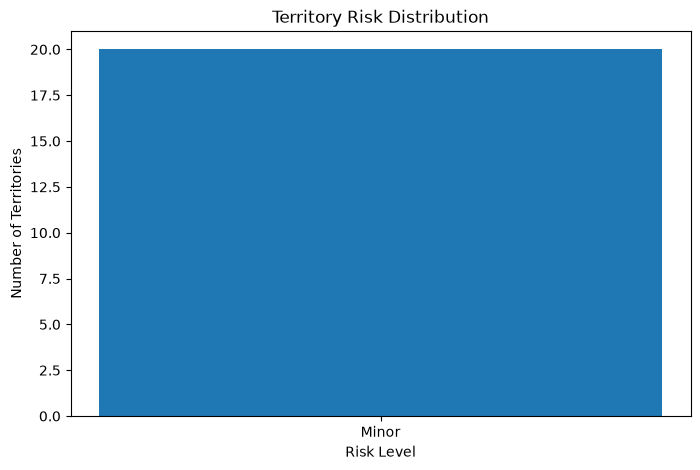

In [90]:
risk_distribution = (
    latest_data["Severity"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_distribution.index,
    risk_distribution.values
)

plt.title("Territory Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Territories")

plt.show()

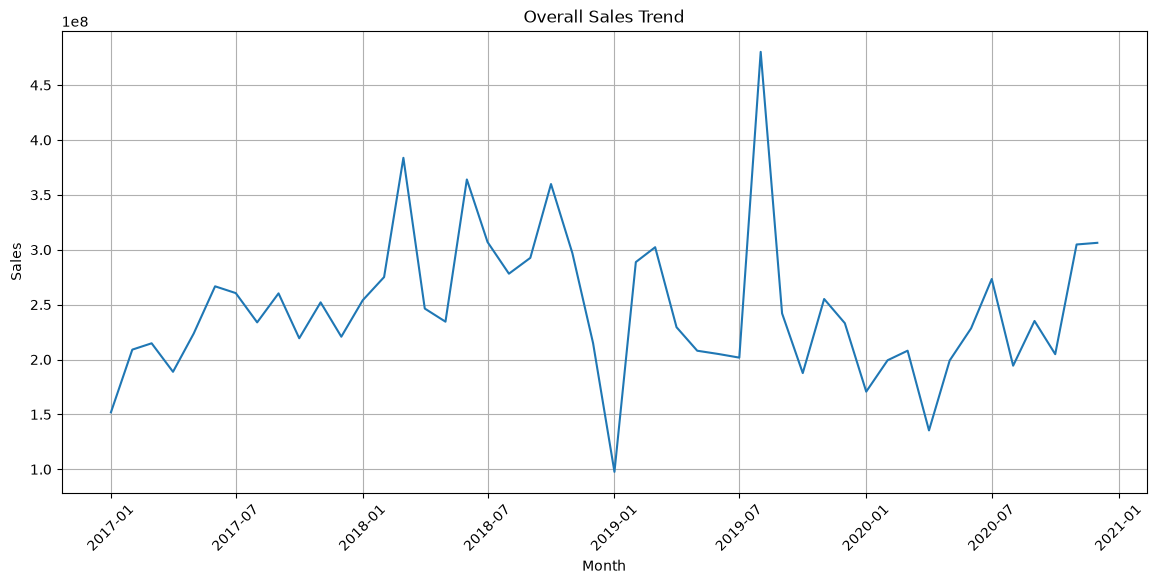

In [91]:
dashboard_sales = (
    ai_df
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_sales["Date"],
    dashboard_sales["Sales"]
)

plt.title("Overall Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

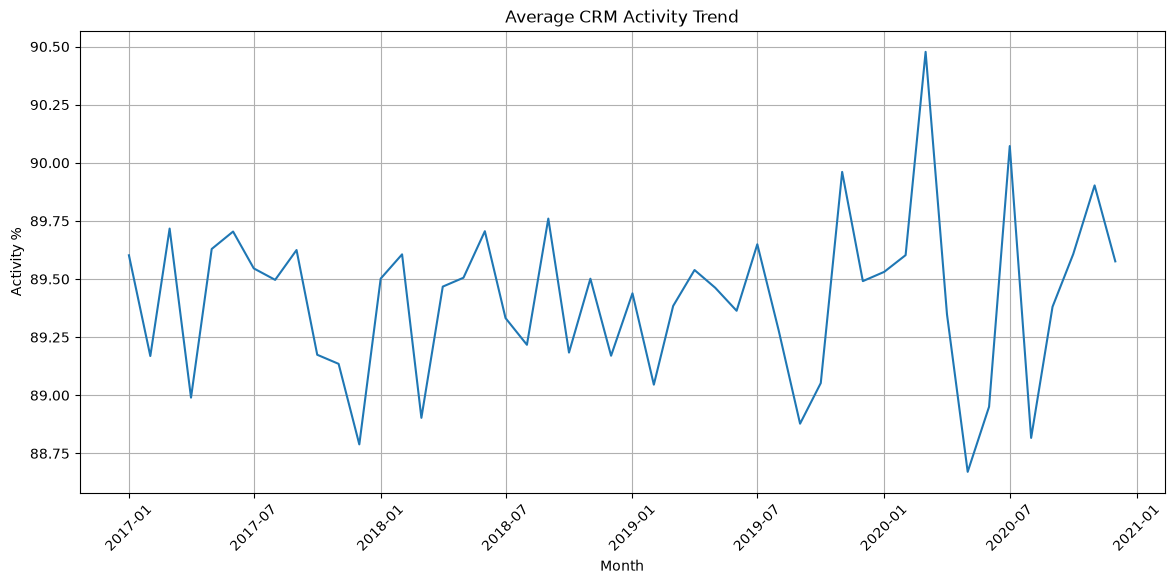

In [92]:
dashboard_crm = (
    ai_df
    .groupby("Date")["Avg_Activity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_crm["Date"],
    dashboard_crm["Avg_Activity"]
)

plt.title("Average CRM Activity Trend")
plt.xlabel("Month")
plt.ylabel("Activity %")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

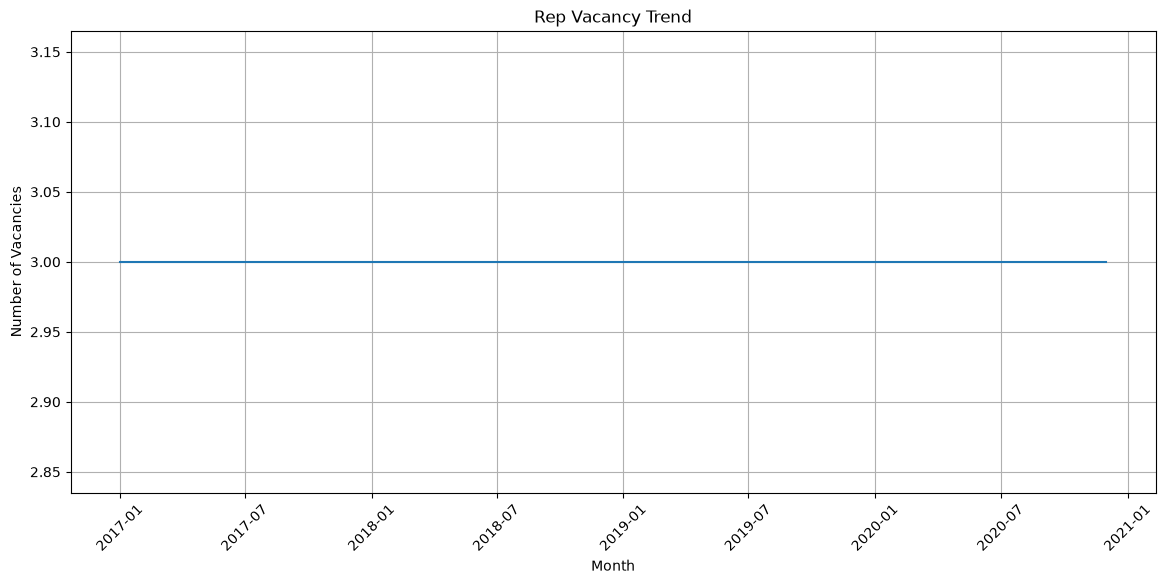

In [93]:
dashboard_vacancy = (
    ai_df
    .groupby("Date")["Vacancies"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_vacancy["Date"],
    dashboard_vacancy["Vacancies"]
)

plt.title("Rep Vacancy Trend")
plt.xlabel("Month")
plt.ylabel("Number of Vacancies")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [94]:
risk_table = (
    latest_data[
        [
            "Territory_ID",
            "Sales",
            "Sales_Change_Pct",
            "Current_Reps",
            "Required_Reps",
            "Vacancies",
            "Max_Vacancy_Days",
            "Avg_Activity",
            "Avg_HCP_Coverage",
            "Anomaly_Score",
            "Final_Risk_Score",
            "Severity",
            "Risk_Reasons",
            "AI_Recommendation"
        ]
    ]
    .sort_values(
        "Final_Risk_Score",
        ascending=False
    )
)

risk_table

,Territory_ID,Sales,Sales_Change_Pct,Current_Reps,Required_Reps,Vacancies,Max_Vacancy_Days,Avg_Activity,Avg_HCP_Coverage,Anomaly_Score,Final_Risk_Score,Severity,Risk_Reasons,AI_Recommendation
143,TERR_03,"33,582,810.00",68.64,1.00,2.00,1.00,320.00,92.51,100.00,62.78,32.14,Minor,1 rep vacancy; Vacancy has remained open for 3...,Continue monitoring.
527,TERR_11,"5,882,209.00",-73.25,NaN,NaN,NaN,NaN,91.32,100.00,12.45,31.02,Minor,Sales dropped 73.3%,Continue monitoring.
767,TERR_16,"13,694,971.00",-53.67,1.00,1.00,0.00,0.00,87.77,100.00,10.33,30.65,Minor,Sales dropped 53.7%,Continue monitoring.
863,TERR_18,"13,741,271.00",-49.99,NaN,NaN,NaN,NaN,89.58,100.00,9.63,30.53,Minor,Sales dropped 50.0%,Continue monitoring.
383,TERR_08,"8,865,415.00",-71.59,NaN,NaN,NaN,NaN,91.14,100.00,8.95,30.41,Minor,Sales dropped 71.6%,Continue monitoring.
191,TERR_04,"19,046,548.00",10.38,4.00,5.00,1.00,565.00,89.60,100.00,44.75,28.99,Minor,1 rep vacancy; Vacancy has remained open for 5...,Continue monitoring.
47,TERR_01,"12,472,018.00",24.13,1.00,2.00,1.00,169.00,87.80,100.00,32.96,26.92,Minor,1 rep vacancy; Vacancy has remained open for 1...,Continue monitoring.
431,TERR_09,"26,407,059.00",104.68,NaN,NaN,NaN,NaN,89.26,100.00,22.94,4.01,Minor,No major business risk indicator detected,Continue monitoring.
575,TERR_12,"8,703,093.00",15.17,NaN,NaN,NaN,NaN,89.95,100.00,15.07,2.64,Minor,No major business risk indicator detected,Continue monitoring.
335,TERR_07,"17,308,994.00",107.14,NaN,NaN,NaN,NaN,91.65,100.00,14.90,2.61,Minor,No major business risk indicator detected,Continue monitoring.


In [95]:
critical_cases_df = (
    risk_table[
        risk_table["Severity"] == "Critical"
    ]
)

print(
    "Critical territories:",
    len(critical_cases_df)
)

critical_cases_df

Critical territories: 0


,Territory_ID,Sales,Sales_Change_Pct,Current_Reps,Required_Reps,Vacancies,Max_Vacancy_Days,Avg_Activity,Avg_HCP_Coverage,Anomaly_Score,Final_Risk_Score,Severity,Risk_Reasons,AI_Recommendation


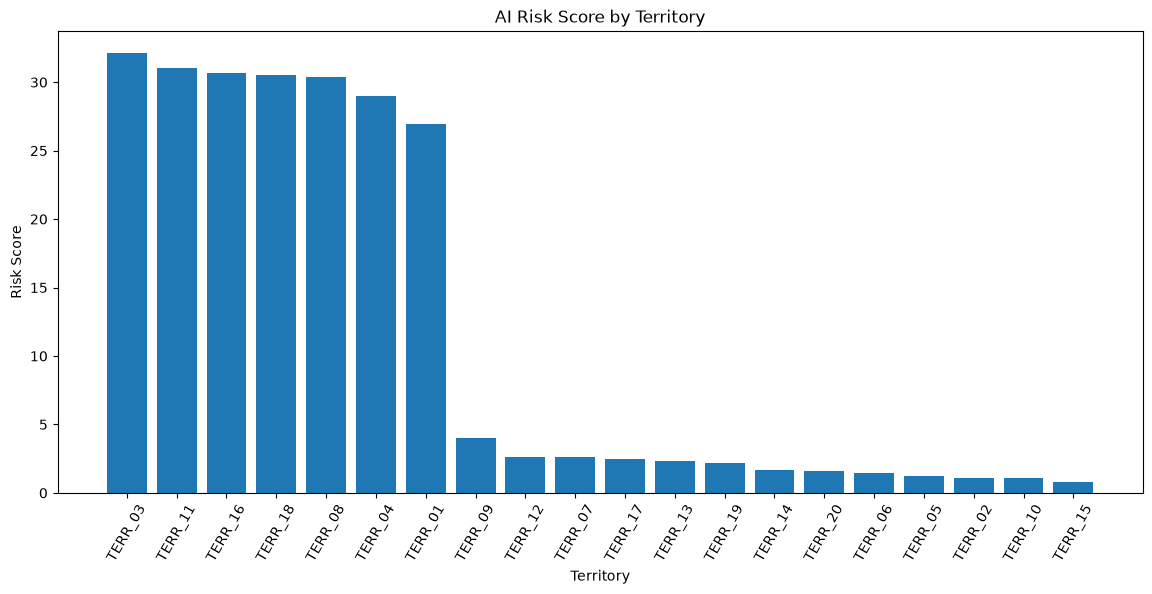

In [96]:
plt.figure(figsize=(14, 6))

territory_risk_plot = (
    latest_data
    .sort_values(
        "Final_Risk_Score",
        ascending=False
    )
)

plt.bar(
    territory_risk_plot["Territory_ID"],
    territory_risk_plot["Final_Risk_Score"]
)

plt.title("AI Risk Score by Territory")
plt.xlabel("Territory")
plt.ylabel("Risk Score")

plt.xticks(rotation=60)

plt.show()

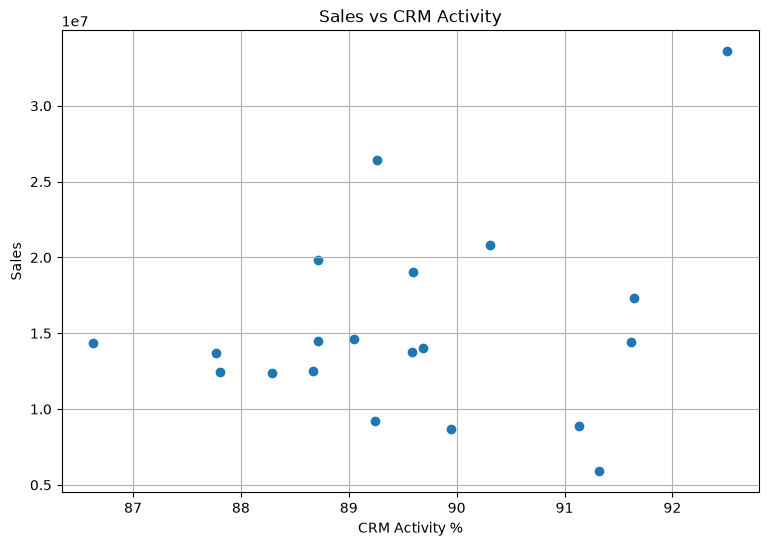

In [97]:
plt.figure(figsize=(9, 6))

plt.scatter(
    latest_data["Avg_Activity"],
    latest_data["Sales"]
)

plt.title("Sales vs CRM Activity")
plt.xlabel("CRM Activity %")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

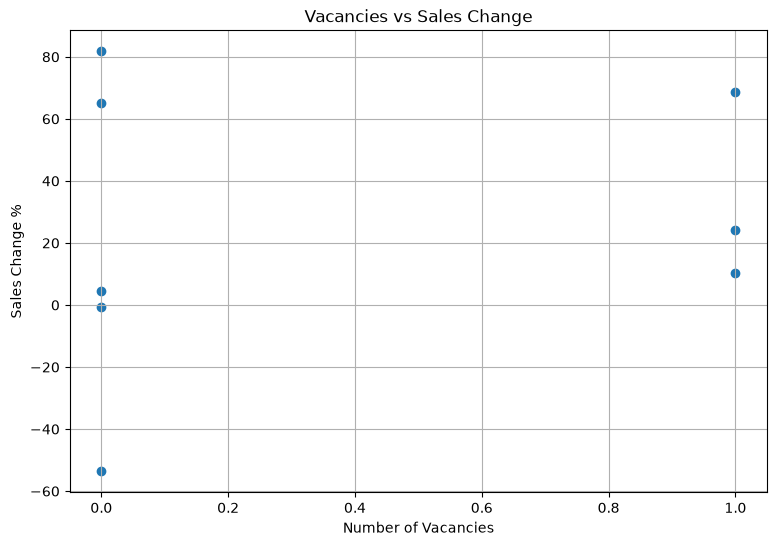

In [98]:
plt.figure(figsize=(9, 6))

plt.scatter(
    latest_data["Vacancies"],
    latest_data["Sales_Change_Pct"]
)

plt.title("Vacancies vs Sales Change")
plt.xlabel("Number of Vacancies")
plt.ylabel("Sales Change %")

plt.grid(True)

plt.show()

In [99]:
executive_dashboard = latest_data[
    [
        "Date",
        "Territory_ID",
        "Sales",
        "Sales_Change_Pct",
        "Current_Reps",
        "Required_Reps",
        "Vacancies",
        "Max_Vacancy_Days",
        "Avg_Activity",
        "Avg_HCP_Coverage",
        "Anomaly_Score",
        "Final_Risk_Score",
        "Severity",
        "Risk_Reasons",
        "AI_Recommendation"
    ]
].copy()

executive_dashboard = (
    executive_dashboard
    .sort_values(
        "Final_Risk_Score",
        ascending=False
    )
)

executive_dashboard.head(20)

,Date,Territory_ID,Sales,Sales_Change_Pct,Current_Reps,Required_Reps,Vacancies,Max_Vacancy_Days,Avg_Activity,Avg_HCP_Coverage,Anomaly_Score,Final_Risk_Score,Severity,Risk_Reasons,AI_Recommendation
143,2020-12-01,TERR_03,"33,582,810.00",68.64,1.00,2.00,1.00,320.00,92.51,100.00,62.78,32.14,Minor,1 rep vacancy; Vacancy has remained open for 3...,Continue monitoring.
527,2020-12-01,TERR_11,"5,882,209.00",-73.25,NaN,NaN,NaN,NaN,91.32,100.00,12.45,31.02,Minor,Sales dropped 73.3%,Continue monitoring.
767,2020-12-01,TERR_16,"13,694,971.00",-53.67,1.00,1.00,0.00,0.00,87.77,100.00,10.33,30.65,Minor,Sales dropped 53.7%,Continue monitoring.
863,2020-12-01,TERR_18,"13,741,271.00",-49.99,NaN,NaN,NaN,NaN,89.58,100.00,9.63,30.53,Minor,Sales dropped 50.0%,Continue monitoring.
383,2020-12-01,TERR_08,"8,865,415.00",-71.59,NaN,NaN,NaN,NaN,91.14,100.00,8.95,30.41,Minor,Sales dropped 71.6%,Continue monitoring.
191,2020-12-01,TERR_04,"19,046,548.00",10.38,4.00,5.00,1.00,565.00,89.60,100.00,44.75,28.99,Minor,1 rep vacancy; Vacancy has remained open for 5...,Continue monitoring.
47,2020-12-01,TERR_01,"12,472,018.00",24.13,1.00,2.00,1.00,169.00,87.80,100.00,32.96,26.92,Minor,1 rep vacancy; Vacancy has remained open for 1...,Continue monitoring.
431,2020-12-01,TERR_09,"26,407,059.00",104.68,NaN,NaN,NaN,NaN,89.26,100.00,22.94,4.01,Minor,No major business risk indicator detected,Continue monitoring.
575,2020-12-01,TERR_12,"8,703,093.00",15.17,NaN,NaN,NaN,NaN,89.95,100.00,15.07,2.64,Minor,No major business risk indicator detected,Continue monitoring.
335,2020-12-01,TERR_07,"17,308,994.00",107.14,NaN,NaN,NaN,NaN,91.65,100.00,14.90,2.61,Minor,No major business risk indicator detected,Continue monitoring.


In [100]:
ai_df.to_csv(
    "AI_rep_management_output.csv",
    index=False
)

executive_dashboard.to_csv(
    "executive_dashboard.csv",
    index=False
)

critical_cases_df.to_csv(
    "critical_territories.csv",
    index=False
)

print('phase 5,6 completed successfully!')

print("\nFiles created:")
print("1. AI_rep_management_output.csv")
print("2. executive_dashboard.csv")
print("3. critical_territories.csv")

phase 5,6 completed successfully!

Files created:
1. AI_rep_management_output.csv
2. executive_dashboard.csv
3. critical_territories.csv


In [101]:
!pip install streamlit plotly scikit-learn pandas numpy

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.5 MB 7.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/10.5 MB 8.0 MB/s eta 0:00:01
   --------------- ------------------------ 4.2/10.5 MB 7.2 MB/s eta 0:00:01
   ---------------------- ----------------- 6.0/10.5 MB 7.3 MB/s eta 0:00:01
   ----------------------------- ---------- 7.9/10.5 MB 7.5 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.5 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.5 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.5 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.5 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.5 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 4.4 MB/s  0:00:02
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   -------